In [1]:
!pip install git+https://github.com/openai/CLIP.git -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00


In [ ]:
import os
import random
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from torchvision.models import ResNet18_Weights
from torch.utils.data import Dataset, DataLoader

import clip
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                              precision_score, recall_score, confusion_matrix)
import seaborn as sns
import torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [ ]:
CONFIG = {
    "base_dir":    "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT",
    "output_dir":  "/kaggle/working/cbm_rdd2022",

    # Path to saved ResNet-18 checkpoint from the other notebook
   "resnet_ckpt": "/kaggle/input/models/ammaraharoonn/resnet18/other/default/1/best_resnet18 (1).pth",

   
    "class_names": [
        "Longitudinal Crack (D00)",
        "Transverse Crack (D10)",
        "Alligator Crack (D20)",
        "Pothole (D40)",
    ],
    "num_classes": 4,
    "img_size":    224,
    "batch_size":  64,
    "num_workers": 2,
    "dropout":     0.5,
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
print("Output dir:", CONFIG["output_dir"])

Output dir: /kaggle/working/cbm_rdd2022


# Generating Concepts for Each Class

### Concept Vocabulary
 Hand-crafted concepts grounded in road inspection standards.
 15 concepts per damage class = 60 total before filtering.
These describe what is VISUALLY present in the image, not the class name.
Phrased as CLIP-friendly descriptions ("a photo showing X")
 generated by claude

In [ ]:
RAW_CONCEPTS = [

    # ── D00: Longitudinal Crack ───────────────────────────────────────────────
    "a road with a narrow crack running parallel to traffic direction",
    "a road surface with a linear fracture along its length",
    "a road with a straight dark line extending along the pavement",
    "a road with a hairline crack following the road axis",
    "a road with a continuous crack parallel to lane markings",
    "a road with a thin elongated gap in asphalt running lengthwise",
    "a road with a dark streak caused by pavement splitting lengthwise",
    "a road with a crack running in the direction vehicles travel",
    "a road with a longitudinal fissure on the paved surface",
    "a road with a single straight crack along its length",
    "a road with a long narrow opening running along the asphalt",
    "a road with a fine line crack parallel to the road edge",
    "a road with asphalt pavement showing a thin linear fracture",
    "a road showing surface separation along a straight line",
    "a road with a crack visible as a dark linear mark on grey pavement",
    "a road with a single crack running lengthwise through the pavement",
    "a road with a surface fracture oriented in the direction of travel",
    "a road with a thin linear split in the asphalt along its axis",
    "a road with a narrow pavement gap extending in the traffic direction",
    "a road with a visible dark line following the lane orientation",
    "a road with a fine crack along the road centreline",
    "a road with a longitudinal split visible across an asphalt surface",
    "a road with a crack that extends parallel to wheel paths",
    "a road with a hairline pavement fracture oriented lengthwise",
    "a road with a slender rupture running along the road surface",
    "a road with asphalt showing a crack aligned with vehicle movement",
    "a road with a linear pavement defect running in the travel direction",
    "a road with a shallow crack oriented along the road edge",
    "a road with a narrow fissure following the length of the carriageway",
    "a road with a dark straight mark caused by a lengthwise pavement crack",
    "a road with a longitudinal crack running close to the outer edge of the lane",
    "a road with a lengthwise crack that widens and narrows along its path",
    "a road with a longitudinal crack partially filled with debris or dirt",
    "a road with a crack running along the length of the road on a wet shiny surface",
    "a road with a fine hairline crack barely visible against dark grey asphalt",
    "a road with a lengthwise crack flanked by smaller secondary micro-cracks",
    "a road where a longitudinal crack passes through a faded white road marking",
    "a road with an irregular longitudinal crack showing jagged rather than straight edges",
    "a road with a lengthwise pavement crack visible under bright overhead lighting",
    "a road with a longitudinal crack showing whitish edges from weathering and oxidation",

    # ── D10: Transverse Crack ─────────────────────────────────────────────────
    "a road with a crack running perpendicular to traffic direction",
    "a road surface with a horizontal fracture crossing the lane width",
    "a road with a straight crack going across the lane side to side",
    "a road with a dark line cutting across the pavement at a right angle",
    "a road with a transverse break across its surface",
    "a road with a crack oriented across the traffic direction",
    "a road surface showing a crack perpendicular to travel direction",
    "a road with a crack spanning the full width of a lane",
    "a road with a visible crosswise fracture in the asphalt",
    "a road with a thin crack running at 90 degrees to lane markings",
    "a road with asphalt cracked in a straight line across the road",
    "a road with a crosswise surface break across the pavement",
    "a road showing a single crack going side to side",
    "a road with pavement split by a fracture running across its width",
    "a road surface with a transverse dark line crack",
    "a road with a crack cutting across the full width of the lane",
    "a road surface with a break oriented perpendicular to vehicle movement",
    "a road with a sharp linear fracture going from one side to the other",
    "a road with a crosswise crack interrupting the pavement surface",
    "a road with a dark line crossing the asphalt at right angles to travel",
    "a road surface split by a crack running across its width",
    "a road with a horizontal crack crossing the pavement from edge to edge",
    "a road with a straight fracture perpendicular to the wheel path",
    "a road with a transverse fissure cutting through the asphalt",
    "a road with a clearly visible crack spanning the lane crosswise",
    "a road with an abrupt break in asphalt oriented across the road axis",
    "a road surface showing a narrow crack running side to side",
    "a road with a crack aligned perpendicular to painted lane markings",
    "a road showing a clean crosswise fracture in the pavement surface",
    "a road with a transverse pavement crack extending across the carriageway",
    "a road with a transverse crack that opens into a wide dark gap across the lane",
    "a road with a crosswise crack showing uneven vertical displacement between sides",
    "a road with multiple closely spaced transverse cracks creating a banded pattern",
    "a road with a transverse crack whose edges have crumbled and eroded over time",
    "a road with a crosswise fracture that continues into the road shoulder or verge",
    "a road with a transverse crack showing signs of prior patching or repair attempt",
    "a road with a narrow transverse crack visible only as a thin dark line across asphalt",
    "a road with a crosswise crack running at a slight diagonal rather than perfectly straight",
    "a road with a transverse crack highlighted by dirt and moisture settling into the gap",
    "a road with a horizontal crack crossing the pavement under flat even lighting conditions",


    # ── D20: Alligator Crack ──────────────────────────────────────────────────
    "a road with interconnected cracks resembling alligator skin",
    "a road with pavement broken into irregular polygonal segments",
    "a road surface covered in a web of interlocking cracks",
    "a road with fatigue cracking forming a mosaic pattern on asphalt",
    "a road with multiple branching cracks forming a mesh pattern",
    "a road surface with chicken-wire shaped crack patterns",
    "a road with block cracking showing interconnected fractures",
    "a road with densely packed irregular cracks covering an area",
    "a road with asphalt showing multi-directional cracks forming closed shapes",
    "a road surface showing severe fatigue with craze cracking",
    "a road with pavement fractured into many small irregular pieces",
    "a road with crocodile skin texture caused by crack network",
    "a road with closely spaced cracks forming a pattern across the surface",
    "a road with asphalt showing map cracking with irregular polygons",
    "a road with a worn surface showing extensive branching crack network",
    "a road surface covered with interlocking angular crack segments",
    "a road with pavement showing a network of irregularly shaped fractures",
    "a road with extensively fractured asphalt resembling a jigsaw pattern",
    "a road with a mosaic of cracks covering a localised area of pavement",
    "a road with fatigue-induced surface cracking forming a cellular pattern",
    "a road with dense multi-directional cracks dividing pavement into pieces",
    "a road with asphalt deterioration showing a craze-cracked surface area",
    "a road with multiple interconnected fractures across a distressed zone",
    "a road with pavement showing load-related cracking in a mesh pattern",
    "a road surface with a complex network of cracks forming irregular blocks",
    "a road with asphalt broken into small angular fragments by fatigue",
    "a road with structural pavement failure visible as branched cracking",
    "a road with cracking spread across an area in a reptile-skin pattern",
    "a road with severe pavement distress showing an interlocked crack web",
    "a road with asphalt split into polygonal sections by surface fatigue",
    "a road with an alligator crack zone showing loose fragments of asphalt within the area",
    "a road with a fatigue-cracked patch where the centre appears lower than the surroundings",
    "a road surface where the cracked zone has a distinctly darker colour than surrounding asphalt",
    "a road with alligator cracking where individual crack cells are large and widely spaced",
    "a road with alligator cracking where individual crack cells are tiny and densely packed",
    "a road with a craze-cracked zone bordered by an abrupt transition to intact asphalt",
    "a road with alligator cracks showing white oxidised edges on each fracture line",
    "a road with a fatigue crack network where moisture has pooled inside the crack cells",
    "a road surface showing alligator cracking alongside a wheel track path",
    "a road with interlocked crack segments forming elongated irregular shapes rather than polygons",

    # ── D40: Pothole ──────────────────────────────────────────────────────────
    "a road with a hole or depression in the pavement surface",
    "a road with a roughly circular cavity in the asphalt",
    "a road with a bowl-shaped excavation in the pavement",
    "a road with missing pavement material leaving a pit",
    "a road with a dark circular depression in the driving lane",
    "a road with a visible cavity where pavement material has been lost",
    "a road with a sunken area in the pavement caused by material failure",
    "a road with an irregular hole in asphalt with broken edges",
    "a road surface showing a deep rounded cavity from structural failure",
    "a road with a pothole showing jagged broken edges in the pavement",
    "a road with asphalt showing a circular void with exposed base material",
    "a road showing structural failure with pavement material loss",
    "a road with a depression in the pavement with crumbling edges",
    "a road with a surface break showing a hole with rough boundaries",
    "a road with a crater-like depression in the driving lane",
    "a road with a concave depression punched through the pavement surface",
    "a road surface showing a pit where asphalt material has broken away",
    "a road with an exposed sub-base material surrounded by crumbling asphalt",
    "a road with a visible cavity creating an uneven driving surface",
    "a road with a rounded excavation in the driving lane with ragged edges",
    "a road with a dark hollow depression in the asphalt pavement",
    "a road surface showing a pavement failure leaving an open void",
    "a road with a bowl-shaped pothole with fractured rim edges",
    "a road with a circular pavement defect showing depth and broken borders",
    "a road with a chunk of asphalt missing leaving an irregular hole",
    "a road surface with a sunken cavity from sub-surface material loss",
    "a road showing a pothole with rough broken asphalt around its perimeter",
    "a road with a localised pavement failure forming a pit in the surface",
    "a road with a deep rounded hole caused by progressive pavement break-up",
    "a road surface with a pothole exposing aggregate beneath the asphalt",
    "a road with a water-filled pothole reflecting light on the surface",
    "a road with a pothole surrounded by alligator cracking indicating structural failure",
    "a road with a small pothole where only the top layer of asphalt has broken away",
    "a road with a large pothole spanning nearly the full width of a vehicle tyre track",
    "a road with a pothole showing exposed gravel or aggregate at its base",
    "a road with multiple small potholes clustered together in a localised area",
    "a road with a pothole whose interior walls show layered asphalt strata",
    "a road with a recently formed pothole with sharp unworn edges around the cavity",
    "a road with an old pothole with smoothed worn edges from repeated vehicle impact",
    "a road with a pothole partially filled with loose gravel or temporary patching material",
]

print(f"Total raw concepts: {len(RAW_CONCEPTS)}")
print(f"Concepts per class: {len(RAW_CONCEPTS) // 4}")
print("\nSample concepts:")
for i, c in enumerate(RAW_CONCEPTS[:4]):
    print(f"  [{i}] {c}")
print("  ...")

Total raw concepts: 160
Concepts per class: 40

Sample concepts:
  [0] a road with a narrow crack running parallel to traffic direction
  [1] a road surface with a linear fracture along its length
  [2] a road with a straight dark line extending along the pavement
  [3] a road with a hairline crack following the road axis
  ...


load CLIP ViT-B/32 and pass all concept strings through its text encoder. Each string becomes a 512-dimensional vector. These vectors live in CLIP's shared embedding space, the same space where images also get encoded. This gives you a matrix of shape [175, 512]

deduplication: if two concept strings are so similar (cosine > 0.98) that CLIP thinks they mean the same thing, drop one. This gives FILTERED_CONCEPTS.

In [ ]:
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)
clip_model.eval()
print(f"CLIP loaded on {DEVICE}")

# Encode all concept strings as CLIP text embeddings
def encode_concepts(concept_list, model, device, batch_size=64):
    """Returns normalized CLIP text embeddings for a list of concept strings."""
    all_embeddings = []
    for i in range(0, len(concept_list), batch_size):
        batch    = concept_list[i:i+batch_size]
        tokens   = clip.tokenize(batch).to(device)
        with torch.no_grad():
            embs = model.encode_text(tokens)
            embs = embs / embs.norm(dim=-1, keepdim=True)   # L2 normalize
        all_embeddings.append(embs.cpu().float())
    return torch.cat(all_embeddings, dim=0)   # [N, 512]

concept_embeddings = encode_concepts(RAW_CONCEPTS, clip_model, DEVICE)
print(f"Concept embeddings shape: {concept_embeddings.shape}")

# Remove near-duplicates: if two concepts have cosine similarity > 0.90,
# keep only the first one encountered
sim_matrix = cosine_similarity(concept_embeddings.numpy())

DEDUP_THRESHOLD = 0.98
keep = []
dropped_dedup = []

for i in range(len(RAW_CONCEPTS)):
    is_duplicate = False
    for j in keep:
        if sim_matrix[i][j] > DEDUP_THRESHOLD:
            is_duplicate = True
            dropped_dedup.append((RAW_CONCEPTS[i], RAW_CONCEPTS[j],
                                  sim_matrix[i][j]))
            break
    if not is_duplicate:
        keep.append(i)

FILTERED_CONCEPTS   = [RAW_CONCEPTS[i] for i in keep]
FILTERED_EMBEDDINGS = concept_embeddings[keep]

print(f"\nAfter deduplication:")
print(f"  Original  : {len(RAW_CONCEPTS)}")
print(f"  Dropped   : {len(dropped_dedup)}")
print(f"  Remaining : {len(FILTERED_CONCEPTS)}")

if dropped_dedup:
    print(f"\nExample duplicates removed:")
    for orig, kept, sim in dropped_dedup[:3]:
        print(f"  sim={sim:.3f}  '{orig}'")
        print(f"           kept: '{kept}'")

# Encode filtered concepts for use in concept grounding
concept_text_embeddings = encode_concepts(FILTERED_CONCEPTS, clip_model, DEVICE)
print(f"Concept text embeddings: {concept_text_embeddings.shape}")

100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 114MiB/s]


CLIP loaded on cuda
Concept embeddings shape: torch.Size([160, 512])

After deduplication:
  Original  : 160
  Dropped   : 0
  Remaining : 160
Concept text embeddings: torch.Size([160, 512])


### Negative Prompting

 1. Clean class assignment via ground-truth RAW_CONCEPTS block boundaries
   2. Per-confuser subtraction weighted by how confusable they are
   3. Alpha sweep with inter-class cosine separation metric
   4. Diagnostic: before/after intra/inter class similarity stats

For each concept embedding $e_i$ belonging to class $y_i$, the class prototype for class $c$ is computed as:

$$
p_c = \frac{1}{N_c} \sum_{k:\, y_k=c} e_k,
\qquad
p_c \leftarrow \frac{p_c}{\|p_c\|}
$$

Confuser similarities are then computed against all non-matching class prototypes:

$$
s_{ij} = \max(0,\, e_i^\top p_j),
\qquad j \neq y_i
$$

These similarities are normalized into weights:

$$
w_{ij} =
\frac{s_{ij}}
{\sum_{k \neq y_i} s_{ik}}
$$

The negative prompting direction is defined as:

$$
n_i =
\sum_{j \neq y_i} w_{ij} p_j
$$

Finally, the refined embedding is obtained by subtracting the weighted confuser direction and re-normalizing:

$$
e_i' =
\frac{
e_i - \alpha n_i
}{
\left\| e_i - \alpha n_i \right\|
}
$$

where $\alpha$ controls the strength of negative prompting.

Ground-truth concept-to-class assignment (from RAW block structure):
  Longitudinal Crack (D00)           :  40 concepts
  Transverse Crack (D10)             :  40 concepts
  Alligator Crack (D20)              :  40 concepts
  Pothole (D40)                      :  40 concepts

Baseline inter-class concept separation: 0.1702

     alpha    inter-class dist       delta
  ------------------------------------------
  alpha=0.00   sep=0.1703   delta=+0.0001 ← best
  alpha=0.05   sep=0.1876   delta=+0.0174 ← best
  alpha=0.10   sep=0.2073   delta=+0.0371 ← best
  alpha=0.15   sep=0.2298   delta=+0.0596 ← best
  alpha=0.20   sep=0.2556   delta=+0.0855 ← best
  alpha=0.25   sep=0.2853   delta=+0.1152 ← best
  alpha=0.30   sep=0.3195   delta=+0.1493 ← best
  alpha=0.40   sep=0.4039   delta=+0.2338 ← best
  alpha=0.50   sep=0.5147   delta=+0.3445 ← best


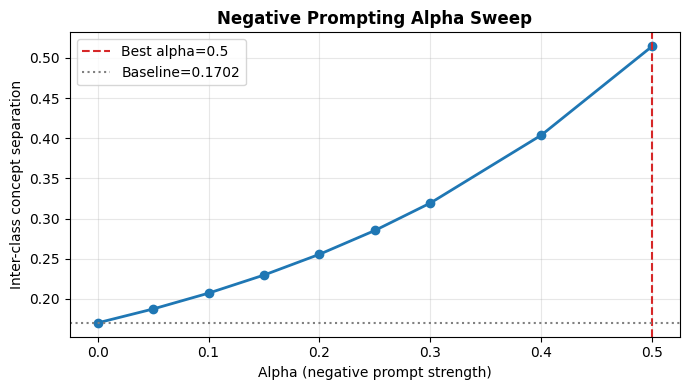


Best alpha: 0.5

Concept space diagnostics (cosine similarity):
  Before: intra=0.8555  inter=0.8298  ratio=1.031  (higher = more discriminative)
  After : intra=0.5903  inter=0.4853  ratio=1.216  (higher = more discriminative)

Average shift: 0.3545

✓ concept_text_embeddings overwritten (alpha=0.5)
  Downstream cells will use the discriminatively-shifted concepts.


In [ ]:
# ground-truth class assignment from RAW_CONCEPTS block structure
RAW_PER_CLASS    = len(RAW_CONCEPTS) // 4   # 40
raw_class_ids    = [i // RAW_PER_CLASS for i in range(len(RAW_CONCEPTS))]
filtered_class_ids = [raw_class_ids[keep[i]] for i in range(len(FILTERED_CONCEPTS))]

print("Ground-truth concept-to-class assignment (from RAW block structure):")
for cls_id, cls_name in enumerate(CONFIG["class_names"]):
    n = sum(1 for c in filtered_class_ids if c == cls_id)
    print(f"  {cls_name:35s}: {n:3d} concepts")

# build per-class prototype embeddings
class_prototypes = []
for cls_id in range(4):
    mask  = torch.tensor([c == cls_id for c in filtered_class_ids])
    proto = FILTERED_EMBEDDINGS[mask].mean(dim=0)
    proto = proto / proto.norm()
    class_prototypes.append(proto)
class_prototypes = torch.stack(class_prototypes)   # [4, 512]

# soft per-confuser subtraction function
def apply_negative_prompting(embeddings, class_ids, prototypes, alpha):
    new_embs = []
    for emb, cls_id in zip(embeddings, class_ids):
        confusers = [j for j in range(4) if j != cls_id]
        conf_sims = torch.stack([
            (emb @ prototypes[j]).clamp(min=0.0)
            for j in confusers
        ])
        if conf_sims.sum() < 1e-8:
            new_embs.append(emb)
            continue
        conf_weights  = conf_sims / conf_sims.sum()
        neg_direction = sum(
            conf_weights[k].item() * prototypes[confusers[k]]
            for k in range(3)
        )
        shifted = emb - alpha * neg_direction
        shifted = shifted / shifted.norm()
        new_embs.append(shifted)
    return torch.stack(new_embs)

# alpha sweep
def inter_class_separation(embeddings, class_ids):
    total, n = 0.0, 0
    for cls_a in range(4):
        for cls_b in range(cls_a + 1, 4):
            mask_a = torch.tensor([c == cls_a for c in class_ids])
            mask_b = torch.tensor([c == cls_b for c in class_ids])
            if mask_a.sum() == 0 or mask_b.sum() == 0:
                continue
            sim_ab  = embeddings[mask_a] @ embeddings[mask_b].T
            dist_ab = 1.0 - sim_ab
            total  += dist_ab.mean().item()
            n      += 1
    return total / n if n > 0 else 0.0

baseline_sep = inter_class_separation(FILTERED_EMBEDDINGS, filtered_class_ids)
print(f"\nBaseline inter-class concept separation: {baseline_sep:.4f}")
print(f"\n  {'alpha':>8}  {'inter-class dist':>18}  {'delta':>10}")
print("  " + "-"*42)

ALPHA_CANDIDATES = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
best_alpha, best_sep = 0.0, baseline_sep
alphas, seps = [], []

for alpha in ALPHA_CANDIDATES:
    shifted = apply_negative_prompting(
        FILTERED_EMBEDDINGS, filtered_class_ids, class_prototypes, alpha)
    sep    = inter_class_separation(shifted, filtered_class_ids)
    delta  = sep - baseline_sep
    marker = " ← best" if sep > best_sep else ""
    alphas.append(alpha)
    seps.append(sep)
    print(f"  alpha={alpha:.2f}   sep={sep:.4f}   delta={delta:+.4f}{marker}")
    if sep > best_sep:
        best_sep   = sep
        best_alpha = alpha

# ── Plot alpha sweep ──────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(alphas, seps, marker="o", linewidth=2, color="tab:blue")
plt.axvline(x=best_alpha, color="tab:red", linestyle="--",
            label=f"Best alpha={best_alpha}")
plt.axhline(y=baseline_sep, color="gray", linestyle=":",
            label=f"Baseline={baseline_sep:.4f}")
plt.xlabel("Alpha (negative prompt strength)")
plt.ylabel("Inter-class concept separation")
plt.title("Negative Prompting Alpha Sweep", fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/negative_prompt_alpha_sweep.png",
            dpi=150, bbox_inches="tight")
plt.show()

NEGATIVE_PROMPT_ALPHA = best_alpha
print(f"\nBest alpha: {NEGATIVE_PROMPT_ALPHA}")

# ── Step 4: apply best alpha ──────────────────────────────────────────────────
contrastive_embs = apply_negative_prompting(
    FILTERED_EMBEDDINGS, filtered_class_ids, class_prototypes, NEGATIVE_PROMPT_ALPHA)

# ── Step 5: diagnostics ───────────────────────────────────────────────────────
print("\nConcept space diagnostics (cosine similarity):")
for label, embs in [("Before", FILTERED_EMBEDDINGS), ("After ", contrastive_embs)]:
    intra_total, inter_total, ni, nx = 0.0, 0.0, 0, 0
    for cls_id in range(4):
        mask     = torch.tensor([c == cls_id for c in filtered_class_ids])
        in_embs  = embs[mask]
        out_embs = embs[~mask]
        n_in = in_embs.shape[0]
        if n_in > 1:
            sim_in    = in_embs @ in_embs.T
            diag_mask = ~torch.eye(n_in, dtype=torch.bool)
            intra_total += sim_in[diag_mask].mean().item()
            ni          += 1
        if out_embs.shape[0] > 0:
            inter_total += (in_embs @ out_embs.T).mean().item()
            nx          += 1
    intra_m = intra_total / ni if ni else 0
    inter_m = inter_total / nx if nx else 0
    ratio   = intra_m / (inter_m + 1e-8)
    print(f"  {label}: intra={intra_m:.4f}  inter={inter_m:.4f}  "
          f"ratio={ratio:.3f}  (higher = more discriminative)")

print(f"\nAverage shift: {(FILTERED_EMBEDDINGS - contrastive_embs).norm(dim=1).mean():.4f}")

# ── Overwrite ─────────────────────────────────────────────────────────────────
concept_text_embeddings = contrastive_embs
print(f"\n✓ concept_text_embeddings overwritten (alpha={NEGATIVE_PROMPT_ALPHA})")
print("  Downstream cells will use the discriminatively-shifted concepts.")

In [ ]:
# Print the final concept list

print("="*65)
print("FINAL CONCEPT VOCABULARY")
print("="*65)

# Group roughly by class for readability
# (concepts stay in their original order for training)
for i, concept in enumerate(FILTERED_CONCEPTS):
    print(f"  [{i:2d}] {concept}")

print(f"\nTotal concepts for bottleneck: {len(FILTERED_CONCEPTS)}")
print("\nThese are the K concepts your bottleneck layer will score.")
print("The cos³ threshold (0.45) will drop any that CLIP can't")
print("reliably ground in road damage imagery during Stage B training.")

# Save concept list
import json
with open(f"{CONFIG['output_dir']}/concepts.json", "w") as f:
    json.dump(FILTERED_CONCEPTS, f, indent=2)
print(f"\nSaved → {CONFIG['output_dir']}/concepts.json")

FINAL CONCEPT VOCABULARY
  [ 0] a road with a narrow crack running parallel to traffic direction
  [ 1] a road surface with a linear fracture along its length
  [ 2] a road with a straight dark line extending along the pavement
  [ 3] a road with a hairline crack following the road axis
  [ 4] a road with a continuous crack parallel to lane markings
  [ 5] a road with a thin elongated gap in asphalt running lengthwise
  [ 6] a road with a dark streak caused by pavement splitting lengthwise
  [ 7] a road with a crack running in the direction vehicles travel
  [ 8] a road with a longitudinal fissure on the paved surface
  [ 9] a road with a single straight crack along its length
  [10] a road with a long narrow opening running along the asphalt
  [11] a road with a fine line crack parallel to the road edge
  [12] a road with asphalt pavement showing a thin linear fracture
  [13] a road showing surface separation along a straight line
  [14] a road with a crack visible as a dark linear ma

# Concept Bottleneck Layer Training

### Rebuild ResNet-18 architecture and load trained weights
load trained best_resnet18.pth and strip off its classification head (the final FC layer). What remains is a function that takes a 224×224 image and outputs a 512-dimensional vector — a compressed representation of the visual content

In [ ]:
backbone = models.resnet18(weights=None)
backbone.fc = nn.Sequential(
    nn.Dropout(p=CONFIG["dropout"]),
    nn.Linear(512, CONFIG["num_classes"])
)


ckpt = torch.load(CONFIG["resnet_ckpt"], map_location=DEVICE)
backbone.load_state_dict(ckpt["model_state"])
backbone = backbone.to(DEVICE)
backbone.eval()
print(f"Loaded ResNet-18 checkpoint")
print(f"  Saved from epoch : {ckpt['epoch']}")
print(f"  Val F1           : {ckpt['val_f1']:.4f}")
print(f"  Val Acc          : {ckpt['val_acc']:.4f}")

# Strip the FC head to get a pure 512-dim feature extractor
# children() gives: conv1, bn1, relu, maxpool, layer1-4, avgpool, fc
# [:-1] removes the fc, keeping everything through avgpool
feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()

# Verify output shape
dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    out = feature_extractor(dummy)
    out = torch.flatten(out, 1)
print(f"\nFeature extractor output: {out.shape}")  # should be [2, 512]

Loaded ResNet-18 checkpoint
  Saved from epoch : 25
  Val F1           : 0.6961
  Val Acc          : 71.7149

Feature extractor output: torch.Size([2, 512])


### Extract ResNet features and CLIP image embeddings for all training images
For every image in the training set (about 27,000 images), run it through two models:

- ResNet feature extractor → gives f ∈ ℝ^512, the backbone features
- CLIP image encoder → gives v ∈ ℝ^512, CLIP's visual embedding

In [ ]:
# We need two things per training image:
#   1. ResNet 512-dim feature vector  → used to train W_c
#   2. CLIP image embedding           → used to compute target concept scores

# Simple dataset — just loads images, applies two different transforms
class ImageOnlyDataset(Dataset):
    def __init__(self, img_paths, resnet_tf, clip_tf):
        self.img_paths = img_paths
        self.resnet_tf = resnet_tf
        self.clip_tf   = clip_tf

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        return self.resnet_tf(img), self.clip_tf(img), str(self.img_paths[idx].name)

# ResNet transform (same as training)
resnet_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# CLIP transform (CLIP has its own required preprocessing)
clip_tf = clip_preprocess  # this is the transform returned by clip.load()

# Get all training image paths
train_img_dir = Path(CONFIG["base_dir"]) / "train" / "images"
all_train_imgs = sorted(train_img_dir.glob("*.jpg"))
print(f"Training images to process: {len(all_train_imgs)}")

# Build loader
img_dataset = ImageOnlyDataset(all_train_imgs, resnet_tf, clip_tf)
img_loader  = DataLoader(img_dataset, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)

# Extract features
all_resnet_features = []   # will be [N, 512]
all_clip_features   = []   # will be [N, 512]

print("Extracting features...")
t0 = time.time()

for i, (resnet_imgs, clip_imgs, _) in enumerate(img_loader):
    with torch.no_grad():
        # ResNet features
        f_resnet = feature_extractor(resnet_imgs.to(DEVICE))
        f_resnet = torch.flatten(f_resnet, 1)          # [B, 512]
        all_resnet_features.append(f_resnet.cpu())

        # CLIP image features
        f_clip = clip_model.encode_image(clip_imgs.to(DEVICE)).float()
        f_clip = f_clip / f_clip.norm(dim=-1, keepdim=True)  # normalize
        all_clip_features.append(f_clip.cpu())

    if (i + 1) % 50 == 0:
        print(f"  [{i+1}/{len(img_loader)}] processed {(i+1)*64} images")

all_resnet_features = torch.cat(all_resnet_features, dim=0)  # [N, 512]
all_clip_features   = torch.cat(all_clip_features,   dim=0)  # [N, 512]

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f}s")
print(f"ResNet features shape : {all_resnet_features.shape}")
print(f"CLIP features shape   : {all_clip_features.shape}")

# Save to disk — this takes a while so save so you don't have to redo it
torch.save(all_resnet_features, f"{CONFIG['output_dir']}/resnet_features_train.pt")
torch.save(all_clip_features,   f"{CONFIG['output_dir']}/clip_features_train.pt")
print("Features saved to disk.")

Training images to process: 26869
Extracting features...
  [50/420] processed 3200 images
  [100/420] processed 6400 images
  [150/420] processed 9600 images
  [200/420] processed 12800 images
  [250/420] processed 16000 images
  [300/420] processed 19200 images
  [350/420] processed 22400 images
  [400/420] processed 25600 images

Done in 725.3s
ResNet features shape : torch.Size([26869, 512])
CLIP features shape   : torch.Size([26869, 512])
Features saved to disk.


For every training image, compute how similar its CLIP image embedding v is to each concept's CLIP text embedding t_k. Since both are L2-normalized, this is just a matrix multiply: all_clip_features @ concept_text_embeddings.T giving shape [N, K]

In [ ]:
def raw_cosine_similarity(image_embs, text_embs):
    """
    Args:
        image_embs: [N, D] normalized CLIP image embeddings
        text_embs:  [K, D] normalized CLIP text embeddings
    Returns:
        [N, K] raw cosine similarities in [-1, 1]
    """
    return image_embs @ text_embs.T   # both already L2 normalized

if 'all_resnet_features' not in dir() or all_resnet_features is None:
    all_resnet_features = torch.load(
        f"{CONFIG['output_dir']}/resnet_features_train.pt")
    print("Loaded ResNet features from disk")
if 'all_clip_features' not in dir() or all_clip_features is None:
    all_clip_features = torch.load(
        f"{CONFIG['output_dir']}/clip_features_train.pt")
    print("Loaded CLIP features from disk")

concept_text_embs_cpu = concept_text_embeddings.cpu()

BATCH = 512
all_raw_cosine = []

for i in range(0, len(all_clip_features), BATCH):
    batch_clip = all_clip_features[i:i+BATCH]   # [B, 512]
    raw_sim    = raw_cosine_similarity(batch_clip, concept_text_embs_cpu)
    all_raw_cosine.append(raw_sim)

all_raw_cosine = torch.cat(all_raw_cosine, dim=0)   # [N, K]

print(f"Raw cosine similarity matrix: {all_raw_cosine.shape}")
print(f"Value range: [{all_raw_cosine.min():.4f}, {all_raw_cosine.max():.4f}]")
print(f"Mean per concept (top 5 by mean):")
mean_raw = all_raw_cosine.mean(dim=0)
top5     = mean_raw.argsort(descending=True)[:5]
for idx in top5.tolist():
    print(f"  [{idx:2d}] mean_cos={mean_raw[idx]:.4f}  {FILTERED_CONCEPTS[idx]}")

Raw cosine similarity matrix: torch.Size([26869, 160])
Value range: [-0.0086, 0.3570]
Mean per concept (top 5 by mean):
  [27] mean_cos=0.2338  a road with a shallow crack oriented along the road edge
  [ 6] mean_cos=0.2335  a road with a dark streak caused by pavement splitting lengthwise
  [101] mean_cos=0.2331  a road with asphalt deterioration showing a craze-cracked surface area
  [ 5] mean_cos=0.2330  a road with a thin elongated gap in asphalt running lengthwise
  [71] mean_cos=0.2319  a road with a crosswise crack showing uneven vertical displacement between sides


### Filter concepts using top-5 mean
For each concept, find the 5 training images where it scored highest, and average those 5 scores. If even the best 5 images score below 0.20 for a concept, CLIP cannot reliably ground that concept in road damage imagery — so we drop it. This gives **STAGE1_CONCEPTS**

In [ ]:
CLIP_CUTOFF = 0.20

# top-5 mean: for each concept, average its 5 highest cosine similarities
top5_mean = torch.mean(
    torch.topk(all_raw_cosine, dim=0, k=5)[0],
    dim=0
)   # [K]

strong_mask    = top5_mean > CLIP_CUTOFF
strong_indices = strong_mask.nonzero(as_tuple=True)[0]
weak_indices   = (~strong_mask).nonzero(as_tuple=True)[0]

print(f"Filtering with top-5 mean threshold: {CLIP_CUTOFF}")
print(f"Concepts before  : {len(FILTERED_CONCEPTS)}")
print(f"Concepts dropped : {len(weak_indices)}")
print(f"Concepts kept    : {len(strong_indices)}")

if len(weak_indices) > 0:
    print("\nDropped:")
    for idx in weak_indices.tolist():
        print(f"  top5={top5_mean[idx]:.4f}  {FILTERED_CONCEPTS[idx]}")

STAGE1_CONCEPTS   = [FILTERED_CONCEPTS[i] for i in strong_indices.tolist()]
STAGE1_TEXT_EMBS  = concept_text_embeddings[strong_indices]
STAGE1_RAW_COSINE = all_raw_cosine[:, strong_indices]   # [N, K1]

print(f"\nStage 1 concepts remaining: {len(STAGE1_CONCEPTS)}")
for i, c in enumerate(STAGE1_CONCEPTS):
    print(f"  [{i:2d}] top5={top5_mean[strong_indices[i]]:.4f}  {c}")

Filtering with top-5 mean threshold: 0.2
Concepts before  : 160
Concepts dropped : 0
Concepts kept    : 160

Stage 1 concepts remaining: 160
  [ 0] top5=0.2882  a road with a narrow crack running parallel to traffic direction
  [ 1] top5=0.3062  a road surface with a linear fracture along its length
  [ 2] top5=0.2855  a road with a straight dark line extending along the pavement
  [ 3] top5=0.3323  a road with a hairline crack following the road axis
  [ 4] top5=0.3048  a road with a continuous crack parallel to lane markings
  [ 5] top5=0.2947  a road with a thin elongated gap in asphalt running lengthwise
  [ 6] top5=0.3079  a road with a dark streak caused by pavement splitting lengthwise
  [ 7] top5=0.3136  a road with a crack running in the direction vehicles travel
  [ 8] top5=0.2980  a road with a longitudinal fissure on the paved surface
  [ 9] top5=0.3223  a road with a single straight crack along its length
  [10] top5=0.2999  a road with a long narrow opening running along 

In [ ]:
val_img_dir = Path(CONFIG["base_dir"]) / "val" / "images"
val_imgs    = sorted(val_img_dir.glob("*.jpg"))

val_dataset     = ImageOnlyDataset(val_imgs, resnet_tf, clip_tf)
val_feat_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"],
                              shuffle=False, num_workers=CONFIG["num_workers"],
                              pin_memory=True)

val_resnet_feats = []
val_clip_feats   = []
feature_extractor.eval()
clip_model.eval()

print(f"Extracting val features ({len(val_imgs)} images)...")
for resnet_imgs, clip_imgs, _ in val_feat_loader:
    with torch.no_grad():
        f_r = feature_extractor(resnet_imgs.to(DEVICE))
        f_r = torch.flatten(f_r, 1).cpu()
        f_c = clip_model.encode_image(clip_imgs.to(DEVICE)).float()
        f_c = f_c / f_c.norm(dim=-1, keepdim=True)
        val_resnet_feats.append(f_r)
        val_clip_feats.append(f_c.cpu())

val_resnet_feats = torch.cat(val_resnet_feats, dim=0)
val_clip_feats   = torch.cat(val_clip_feats,   dim=0)

# Val CLIP-concept cosine similarities
val_raw_cosine = val_clip_feats @ STAGE1_TEXT_EMBS.T   # [Nv, K1]
print(f"Val ResNet features : {val_resnet_feats.shape}")
print(f"Val CLIP cosine     : {val_raw_cosine.shape}")

Extracting val features (5758 images)...
Val ResNet features : torch.Size([5758, 512])
Val CLIP cosine     : torch.Size([5758, 160])


### Train W_c with similarity function
W_c is a linear layer mapping 512 ResNet features → K concept scores.
You train it using the paper's cos_similarity_cubed_single loss:

- Take a batch of training images
- Run their ResNet features through W_c to get projected outputs [B, K]
- Compare those outputs to the CLIP-derived target similarities [B, K]
- The loss maximizes alignment between what W_c produces and what CLIP says the concept scores should be
- Early stop when validation alignment stops improving

After training, W_c has learned to reproduce CLIP's concept knowledge from ResNet features alone. At inference time, CLIP is no longer needed.

In [ ]:
def cos_similarity_cubed_single(clip_feats, target_feats):
    """
    Exact implementation from LF-CBM paper (similarity.py).
    
    clip_feats:   [B, K] — CLIP cosine similarities for batch of images
    target_feats: [B, K] — projection layer output for same batch
    
    Returns: [K] per-concept similarity score
    
    Key difference from naive cos³:
    - Subtracts column mean before cubing (mean-centers each concept)
    - Normalizes column-wise (across images, not across concepts)
    - Compares concept-by-concept (column k vs column k)
    """
    clip_feats   = clip_feats.float()
    target_feats = target_feats.float()

    # Step 1: subtract column mean (mean-center each concept's distribution)
    clip_feats   = clip_feats   - torch.mean(clip_feats,   dim=0, keepdim=True)
    target_feats = target_feats - torch.mean(target_feats, dim=0, keepdim=True)

    # Step 2: cube
    clip_feats   = clip_feats   ** 3
    target_feats = target_feats ** 3

    # Step 3: column-wise L2 normalize
    clip_feats   = clip_feats   / torch.norm(clip_feats,   p=2, dim=0, keepdim=True).clamp(min=1e-8)
    target_feats = target_feats / torch.norm(target_feats, p=2, dim=0, keepdim=True).clamp(min=1e-8)

    # Step 4: column-wise dot product → [K] similarities
    similarities = torch.sum(target_feats * clip_feats, dim=0)
    return similarities


K1         = len(STAGE1_CONCEPTS)
proj_layer = nn.Linear(512, K1, bias=False).to(DEVICE)
opt        = torch.optim.Adam(proj_layer.parameters(), lr=1e-3)

N          = all_resnet_features.shape[0]
PROJ_STEPS = 1000
PROJ_BATCH = min(50000, N)
indices    = list(range(N))

best_val_loss = float("inf")
best_step     = 0
best_weights  = None

print(f"Training W_c: 512 → {K1} concepts")
print(f"Using paper's cos_similarity_cubed_single (mean-centered, column-wise)")
print(f"Steps: {PROJ_STEPS}  Batch: {PROJ_BATCH}")
print("-"*55)

for step in range(PROJ_STEPS):
    proj_layer.train()

    batch_idx    = torch.LongTensor(random.sample(indices, k=PROJ_BATCH))
    target_batch = all_resnet_features[batch_idx].to(DEVICE)  # [B, 512]
    clip_batch   = STAGE1_RAW_COSINE[batch_idx].to(DEVICE)    # [B, K1]

    outs = proj_layer(target_batch.detach())   # [B, K1]
    loss = -cos_similarity_cubed_single(clip_batch.detach(), outs)
    loss = torch.mean(loss)

    loss.backward()
    opt.step()
    opt.zero_grad()

    # Validate every 50 steps — early stop if val loss increases
    if step % 50 == 0 or step == PROJ_STEPS - 1:
        proj_layer.eval()
        with torch.no_grad():
            val_out  = proj_layer(val_resnet_feats.to(DEVICE).detach())
            val_loss = -cos_similarity_cubed_single(
                val_raw_cosine.to(DEVICE).detach(), val_out
            )
            val_loss = torch.mean(val_loss)

        print(f"  Step {step:4d}  "
              f"train_sim={-loss.item():.4f}  "
              f"val_sim={-val_loss.item():.4f}")

        if step == 0:
            best_val_loss = val_loss.item()
            best_step     = step
            best_weights  = proj_layer.weight.clone()
        elif val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_step     = step
            best_weights  = proj_layer.weight.clone()
        else:
            print(f"  Val loss increasing — early stopping at step {step}")
            break

proj_layer.load_state_dict({"weight": best_weights})
print(f"\nBest step: {best_step}  "
      f"Best val similarity: {-best_val_loss:.4f}")

Training W_c: 512 → 160 concepts
Using paper's cos_similarity_cubed_single (mean-centered, column-wise)
Steps: 1000  Batch: 26869
-------------------------------------------------------
  Step    0  train_sim=0.0017  val_sim=0.0522
  Step   50  train_sim=0.5374  val_sim=0.5386
  Step  100  train_sim=0.6137  val_sim=0.6006
  Step  150  train_sim=0.6529  val_sim=0.6222
  Step  200  train_sim=0.6767  val_sim=0.6322
  Step  250  train_sim=0.6922  val_sim=0.6371
  Step  300  train_sim=0.7021  val_sim=0.6396
  Step  350  train_sim=0.7085  val_sim=0.6397
  Step  400  train_sim=0.7126  val_sim=0.6392
  Val loss increasing — early stopping at step 400

Best step: 350  Best val similarity: 0.6397


After training W_c, run the validation images through it and check whether W_c actually learned each concept well. Compute the cos³ similarity between W_c's output and CLIP's target for each concept on the val set. Any concept where W_c's alignment is still below 0.20 gets dropped — W_c failed to learn it reliably. This gives FINAL_CONCEPTS and the final W_c matrix.

In [ ]:
INTERPRETABILITY_CUTOFF = 0.20

proj_layer.eval()
with torch.no_grad():
    val_out = proj_layer(val_resnet_feats.to(DEVICE).detach())
    # Use paper's similarity function — same as training
    per_concept_sim = cos_similarity_cubed_single(
        val_raw_cosine.to(DEVICE).detach(), val_out
    )   # [K1]

interpretable = per_concept_sim > INTERPRETABILITY_CUTOFF

print(f"Interpretability cutoff : {INTERPRETABILITY_CUTOFF}")
print(f"Concepts before         : {K1}")
print(f"Concepts dropped        : {(~interpretable).sum().item()}")
print(f"Concepts kept           : {interpretable.sum().item()}")

print("\nPer-concept interpretability scores:")
for i, (concept, sim) in enumerate(
    zip(STAGE1_CONCEPTS, per_concept_sim.cpu().tolist())
):
    status = "✓" if interpretable[i] else "✗"
    print(f"  {status}  {sim:.4f}  {concept}")

FINAL_CONCEPTS   = [STAGE1_CONCEPTS[i]
                    for i in range(len(STAGE1_CONCEPTS)) if interpretable[i]]
W_c              = proj_layer.weight[interpretable]

proj_layer_final = nn.Linear(512, len(FINAL_CONCEPTS), bias=False)
proj_layer_final.load_state_dict({"weight": W_c})
proj_layer_final = proj_layer_final.to(DEVICE)
proj_layer_final.eval()

K = len(FINAL_CONCEPTS)
print(f"\nFinal concept count: {K}")

with open(f"{CONFIG['output_dir']}/final_concepts.json", "w") as f:
    json.dump(FINAL_CONCEPTS, f, indent=2)
torch.save(W_c, f"{CONFIG['output_dir']}/W_c.pt")
print("Saved.")

Interpretability cutoff : 0.2
Concepts before         : 160
Concepts dropped        : 0
Concepts kept           : 160

Per-concept interpretability scores:
  ✓  0.3983  a road with a narrow crack running parallel to traffic direction
  ✓  0.6886  a road surface with a linear fracture along its length
  ✓  0.6148  a road with a straight dark line extending along the pavement
  ✓  0.7262  a road with a hairline crack following the road axis
  ✓  0.6350  a road with a continuous crack parallel to lane markings
  ✓  0.4937  a road with a thin elongated gap in asphalt running lengthwise
  ✓  0.6991  a road with a dark streak caused by pavement splitting lengthwise
  ✓  0.7131  a road with a crack running in the direction vehicles travel
  ✓  0.4571  a road with a longitudinal fissure on the paved surface
  ✓  0.6688  a road with a single straight crack along its length
  ✓  0.6276  a road with a long narrow opening running along the asphalt
  ✓  0.6872  a road with a fine line crack paralle

### Compute concept scores for all splits

Run every image in train, val, and test through: feature_extractor → W_c → concept scores [K]. 

Then normalize these scores using train mean and std (subtract mean, divide by std). This normalization is important because it makes all concept scores comparable in scale before the linear classifier sees them.

In [ ]:
def get_concept_scores(split, proj_layer, feature_extractor, config, tf):
    img_dir = Path(config["base_dir"]) / split / "images"
    lbl_dir = Path(config["base_dir"]) / split / "labels"
    remap   = {0: 0, 1: 1, 2: 2, 3: 3}
    all_scores, all_labels = [], []
    skipped = 0
    proj_layer.eval()
    feature_extractor.eval()

    for img_path in sorted(img_dir.glob("*.jpg")):
        txt_path = lbl_dir / (img_path.stem + ".txt")
        if not txt_path.exists():
            skipped += 1
            continue
        try:
            ids = []
            with open(txt_path) as f:
                for line in f:
                    p = line.strip().split()
                    if len(p) == 5 and int(p[0]) in remap:
                        ids.append(remap[int(p[0])])
            if not ids:
                skipped += 1
                continue
            label = Counter(ids).most_common(1)[0][0]
        except Exception:
            skipped += 1
            continue

        img   = Image.open(img_path).convert("RGB")
        img_t = tf(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            feat  = feature_extractor(img_t)
            feat  = torch.flatten(feat, 1)
            score = proj_layer(feat).cpu()
        all_scores.append(score)
        all_labels.append(label)

    scores = torch.cat(all_scores, dim=0)
    labels = torch.tensor(all_labels)
    print(f"[{split.upper()}] {len(labels)} images  (skipped {skipped})")
    return scores, labels

print("Computing concept scores for all splits...")
train_c, train_y = get_concept_scores("train", proj_layer_final, feature_extractor, CONFIG, resnet_tf)
val_c,   val_y   = get_concept_scores("val",   proj_layer_final, feature_extractor, CONFIG, resnet_tf)
test_c,  test_y  = get_concept_scores("test",  proj_layer_final, feature_extractor, CONFIG, resnet_tf)

# Normalize with train statistics (paper does this)
train_mean = train_c.mean(dim=0, keepdim=True)
train_std  = train_c.std(dim=0,  keepdim=True).clamp(min=1e-8)
train_c_norm = (train_c - train_mean) / train_std
val_c_norm   = (val_c   - train_mean) / train_std
test_c_norm  = (test_c  - train_mean) / train_std

print(f"\nNormalized score range: [{train_c_norm.min():.3f}, {train_c_norm.max():.3f}]")

torch.save(train_mean, f"{CONFIG['output_dir']}/proj_mean.pt")
torch.save(train_std,  f"{CONFIG['output_dir']}/proj_std.pt")
torch.save((train_c_norm, train_y), f"{CONFIG['output_dir']}/concept_scores_train.pt")
torch.save((val_c_norm,   val_y),   f"{CONFIG['output_dir']}/concept_scores_val.pt")
torch.save((test_c_norm,  test_y),  f"{CONFIG['output_dir']}/concept_scores_test.pt")
print("Saved normalized concept scores.")

Computing concept scores for all splits...
[TRAIN] 17902 images  (skipped 8967)
[VAL] 3743 images  (skipped 2015)
[TEST] 3785 images  (skipped 1973)

Normalized score range: [-6.168, 5.641]
Saved normalized concept scores.


# Sparse Classifier Training (Vanilla LF-CBM)

###  Train sparse linear classifier
The final classifier is a logistic regression with elastic net regularization. Input: K normalized concept scores. Output: 4 class probabilities. The elastic net forces most weights to exactly zero. This sparsity is what makes the model interpretable: you can look at the nonzero weights and read off exactly which concepts drive each damage classification.

In [ ]:
X_train = train_c_norm.numpy()
y_train = train_y.numpy()
X_val   = val_c_norm.numpy()
y_val   = val_y.numpy()
X_test  = test_c_norm.numpy()
y_test  = test_y.numpy()

# Find best C via validation F1 
C_values = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]

print(f"{'C':>8}  {'Val F1':>8}  {'Avg nonzero':>12}")
print("-" * 40)

best_clf    = None
best_val_f1 = 0.0
best_C      = None

for C in C_values:
    clf_candidate = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        C=C,
        max_iter=3000,
        random_state=42,
    )
    clf_candidate.fit(X_train, y_train)
    val_preds   = clf_candidate.predict(X_val)
    val_f1      = f1_score(y_val, val_preds, average="macro", zero_division=0)
    coef        = clf_candidate.coef_
    nonzero     = (np.abs(coef) > 1e-4).sum(axis=1)
    avg_nonzero = nonzero.mean()

    print(f"  C={C:<6}  F1={val_f1:.4f}  avg_nonzero={avg_nonzero:.0f}/{K}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_clf    = clf_candidate
        best_C      = C

clf      = best_clf
chosen_C = best_C
print(f"\nBest C by val F1: {chosen_C}  (val F1={best_val_f1:.4f})")

# note : we overwrite this later, this is only best c by f1
coef    = clf.coef_
nonzero = (np.abs(coef) > 1e-4).sum(axis=1)
print(f"\nFinal classifier (C={chosen_C}):")
print(f"Nonzero concept weights per class:")
for name, nz in zip(CONFIG["class_names"], nonzero):
    bar = "█" * nz
    print(f"  {name:35s}: {nz:3d}/{K}  {bar}")
print(f"\nAverage nonzero: {nonzero.mean():.0f}/{K}")

       C    Val F1   Avg nonzero
----------------------------------------
  C=0.01    F1=0.5719  avg_nonzero=50/160
  C=0.03    F1=0.6014  avg_nonzero=83/160
  C=0.1     F1=0.6154  avg_nonzero=117/160
  C=0.3     F1=0.6181  avg_nonzero=137/160
  C=1.0     F1=0.6166  avg_nonzero=146/160
  C=3.0     F1=0.6155  avg_nonzero=156/160
  C=10.0    F1=0.6152  avg_nonzero=160/160

Best C by val F1: 0.3  (val F1=0.6181)

Final classifier (C=0.3):
Nonzero concept weights per class:
  Longitudinal Crack (D00)           : 140/160  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Transverse Crack (D10)             : 140/160  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Alligator Crack (D20)              : 136/160  ███████████████████████████████████████████████████████████████████████████████████████████████████

### F1 vs Sparsity Trade-off Analysis

       C    Val F1   Test F1   Avg nonzero
--------------------------------------------------
  C=0.001   0.4182    0.4260    10/160
  C=0.003   0.5193    0.5235    22/160
  C=0.01    0.5719    0.5824    50/160
  C=0.03    0.6014    0.6131    83/160
  C=0.04    0.6069    0.6185    93/160
  C=0.05    0.6104    0.6223    102/160
  C=0.06    0.6138    0.6205    106/160
  C=0.1     0.6154    0.6249    117/160
  C=0.3     0.6181    0.6301    137/160


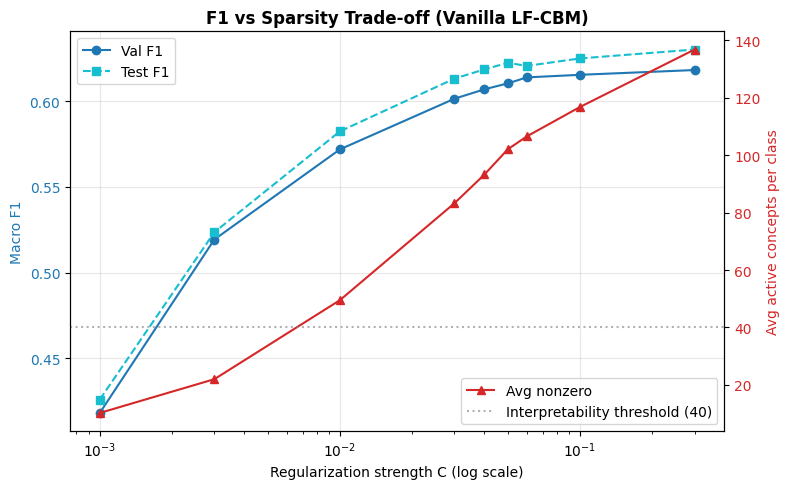


Operating point recommendations:
  Peak F1     : C=0.3     val_f1=0.6181  avg_nz=137/160
  Interpretable (avg_nz ≤ 40):
             : C=0.003   val_f1=0.5193  avg_nz=22/160
  F1 cost of interpretability: +0.0988


In [ ]:
# Sweeps C across a wide range and plots how validation F1 trades off against
# the average number of active concepts per class. Used to select an operating
# point that balances accuracy with interpretability.

C_values = [0.001, 0.003, 0.01, 0.03, 0.04, 0.05, 0.06, 0.1, 0.3 ]

sweep_results = []

print(f"{'C':>8}  {'Val F1':>8}  {'Test F1':>8}  {'Avg nonzero':>12}")
print("-" * 50)

for C in C_values:
    clf_c = LogisticRegression(
        penalty="elasticnet", solver="saga",
        l1_ratio=0.5, C=C, max_iter=3000,
        random_state=42,
    )
    clf_c.fit(X_train, y_train)

    val_f1  = f1_score(y_val,  clf_c.predict(X_val),  average="macro", zero_division=0)
    test_f1 = f1_score(y_test, clf_c.predict(X_test), average="macro", zero_division=0)
    nz_per_class = (np.abs(clf_c.coef_) > 1e-4).sum(axis=1)
    avg_nz       = nz_per_class.mean()

    sweep_results.append({
        "C": C, "val_f1": val_f1, "test_f1": test_f1, "avg_nonzero": avg_nz,
    })
    print(f"  C={C:<6}  {val_f1:.4f}    {test_f1:.4f}    {avg_nz:.0f}/{K}")

# ── Plot
Cs        = [r["C"]           for r in sweep_results]
val_f1s   = [r["val_f1"]      for r in sweep_results]
test_f1s  = [r["test_f1"]     for r in sweep_results]
nonzeros  = [r["avg_nonzero"] for r in sweep_results]

fig, ax1 = plt.subplots(figsize=(8, 5))

color1 = "tab:blue"
ax1.set_xlabel("Regularization strength C (log scale)")
ax1.set_ylabel("Macro F1", color=color1)
ax1.set_xscale("log")
ax1.plot(Cs, val_f1s,  marker="o", color="tab:blue",   label="Val F1")
ax1.plot(Cs, test_f1s, marker="s", color="tab:cyan",   label="Test F1", linestyle="--")
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")

ax2    = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Avg active concepts per class", color=color2)
ax2.plot(Cs, nonzeros, marker="^", color=color2, label="Avg nonzero")
ax2.tick_params(axis="y", labelcolor=color2)
ax2.axhline(y=40, color="gray", linestyle=":", alpha=0.6,
            label="Interpretability threshold (40)")
ax2.legend(loc="lower right")

plt.title("F1 vs Sparsity Trade-off (Vanilla LF-CBM)", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/f1_vs_sparsity_tradeoff.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "="*60)
print("Operating point recommendations:")
print("="*60)
peak       = max(sweep_results, key=lambda r: r["val_f1"])
interp     = [r for r in sweep_results if r["avg_nonzero"] <= 40]
best_interp = max(interp, key=lambda r: r["val_f1"]) if interp else None

print(f"  Peak F1     : C={peak['C']:<6}  "
      f"val_f1={peak['val_f1']:.4f}  "
      f"avg_nz={peak['avg_nonzero']:.0f}/{K}")
if best_interp:
    print(f"  Interpretable (avg_nz ≤ 40):")
    print(f"             : C={best_interp['C']:<6}  "
          f"val_f1={best_interp['val_f1']:.4f}  "
          f"avg_nz={best_interp['avg_nonzero']:.0f}/{K}")
    delta = peak["val_f1"] - best_interp["val_f1"]
    print(f"  F1 cost of interpretability: {delta:+.4f}")
else:
    print("  No C achieved avg_nz ≤ 40")

In [ ]:
CHOSEN_C = 0.04   # selected from F1-vs-sparsity trade-off
clf = LogisticRegression(
    penalty="elasticnet", solver="saga",
    l1_ratio=0.5, C=CHOSEN_C,
    max_iter=3000, random_state=42,
)
clf.fit(X_train, y_train)

coef    = clf.coef_
nonzero = (np.abs(coef) > 1e-4).sum(axis=1)
print(f"Final classifier (C={CHOSEN_C}):")
print(f"Nonzero concept weights per class:")
for name, nz in zip(CONFIG["class_names"], nonzero):
    bar = "█" * nz
    print(f"  {name:35s}: {nz:3d}/{K}  {bar}")
print(f"\nAverage nonzero: {nonzero.mean():.0f}/{K}")

Final classifier (C=0.04):
Nonzero concept weights per class:
  Longitudinal Crack (D00)           :  99/160  ███████████████████████████████████████████████████████████████████████████████████████████████████
  Transverse Crack (D10)             :  90/160  ██████████████████████████████████████████████████████████████████████████████████████████
  Alligator Crack (D20)              : 108/160  ████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Pothole (D40)                      :  76/160  ████████████████████████████████████████████████████████████████████████████

Average nonzero: 93/160


### Evaluate and compare
Run on test set, compute F1/accuracy/precision/recall, plot confusion matrix, compare against ResNet-18 baseline.

VANILLA LF-CBM — TEST RESULTS
  Accuracy          : 66.26%
  F1 (macro)        : 0.6185
  F1 (weighted)     : 0.6556
  Precision (macro) : 0.6365
  Recall (macro)    : 0.6104
  Num concepts used : 160
                          precision    recall  f1-score   support

Longitudinal Crack (D00)       0.72      0.80      0.76      1609
  Transverse Crack (D10)       0.59      0.41      0.48       582
   Alligator Crack (D20)       0.63      0.66      0.64       778
           Pothole (D40)       0.61      0.58      0.59       816

                accuracy                           0.66      3785
               macro avg       0.64      0.61      0.62      3785
            weighted avg       0.66      0.66      0.66      3785



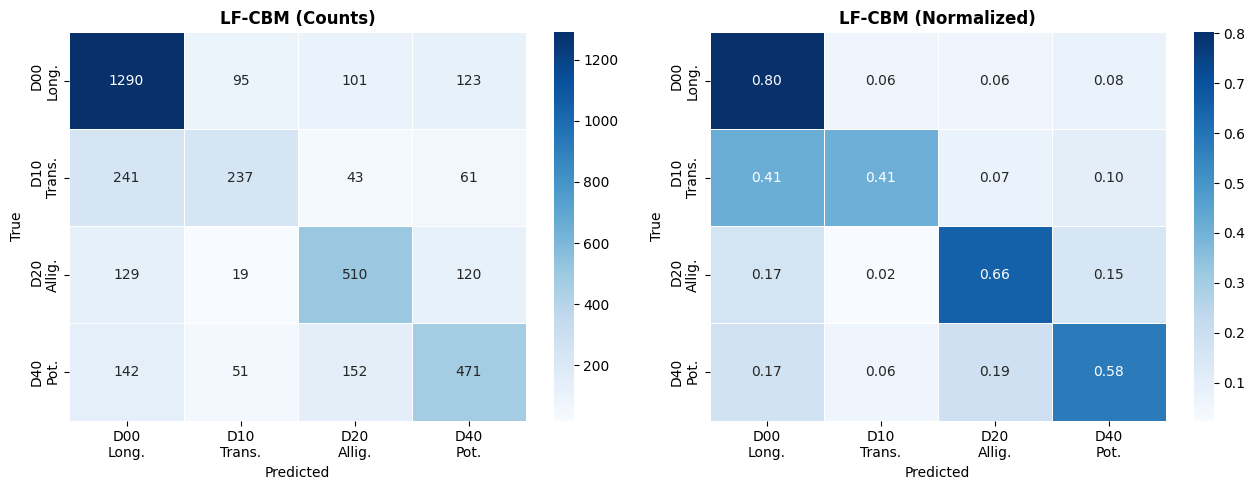

Saved metrics → /kaggle/working/cbm_rdd2022/metrics_vanilla_cbm.json


In [ ]:
test_preds = clf.predict(X_test)
test_f1    = f1_score(test_y, test_preds, average="macro",    zero_division=0)
test_f1_wt = f1_score(test_y, test_preds, average="weighted", zero_division=0)
test_acc   = accuracy_score(test_y, test_preds) * 100
test_prec  = precision_score(test_y, test_preds, average="macro", zero_division=0)
test_rec   = recall_score(test_y,    test_preds, average="macro", zero_division=0)

print("="*50)
print("VANILLA LF-CBM — TEST RESULTS")
print("="*50)
print(f"  Accuracy          : {test_acc:.2f}%")
print(f"  F1 (macro)        : {test_f1:.4f}")
print(f"  F1 (weighted)     : {test_f1_wt:.4f}")
print(f"  Precision (macro) : {test_prec:.4f}")
print(f"  Recall (macro)    : {test_rec:.4f}")
print(f"  Num concepts used : {K}")
print("="*50)

print(classification_report(test_y, test_preds,
                             target_names=CONFIG["class_names"],
                             zero_division=0))

cbm_metrics = {
    "model":           "Vanilla LF-CBM",
    "num_concepts":    K,
    "accuracy":        round(test_acc, 4),
    "f1_macro":        round(test_f1, 4),
    "f1_weighted":     round(test_f1_wt, 4),
    "precision_macro": round(test_prec, 4),
    "recall_macro":    round(test_rec, 4),
}
with open(f"{CONFIG['output_dir']}/metrics_vanilla_cbm.json", "w") as f:
    json.dump(cbm_metrics, f, indent=2)

cm  = confusion_matrix(test_y, test_preds)
cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
tags = ["D00\nLong.", "D10\nTrans.", "D20\nAllig.", "D40\nPot."]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, fmt, title in zip(
    axes, [cm, cmn], ["d", ".2f"], ["Counts", "Normalized"]
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=tags, yticklabels=tags, ax=ax,
                linewidths=0.5, linecolor="white")
    ax.set_title(f"LF-CBM ({title})", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/confusion_matrix_cbm.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved metrics → {CONFIG['output_dir']}/metrics_vanilla_cbm.json")

In [ ]:
# Comparison table

resnet_metrics_path = "/kaggle/input/datasets/ammaraharoonn/metrics/metrics (1).json"

if os.path.exists(resnet_metrics_path):
    with open(resnet_metrics_path) as f:
        resnet_metrics = json.load(f)
else:
    # Placeholder if not saved — fill in manually from your baseline notebook
    resnet_metrics = {
        "f1_macro": None, "accuracy": None,
        "precision_macro": None, "recall_macro": None
    }
    print("WARNING: ResNet metrics file not found. Fill in manually.")

print("\n" + "="*65)
print("RESULTS COMPARISON TABLE")
print("="*65)
print(f"{'Metric':<25} {'ResNet-18':>12} {'Vanilla LF-CBM':>15}")
print("-"*65)

metrics_to_show = [
    ("Accuracy (%)",    "accuracy"),
    ("F1 Macro",        "f1_macro"),
    ("F1 Weighted",     "f1_weighted"),
    ("Precision Macro", "precision_macro"),
    ("Recall Macro",    "recall_macro"),
]

for display_name, key in metrics_to_show:
    r_val = resnet_metrics.get(key, "N/A")
    c_val = cbm_metrics.get(key, "N/A")
    r_str = f"{r_val:.4f}" if isinstance(r_val, float) else str(r_val)
    c_str = f"{c_val:.4f}" if isinstance(c_val, float) else str(c_val)
    print(f"  {display_name:<23} {r_str:>12} {c_str:>15}")

print("-"*65)
print(f"  {'Interpretable':<23} {'No':>12} {'Yes':>15}")
print(f"  {'Num concepts':<23} {'N/A':>12} {K:>15}")
print(f"  {'Concept interventions':<23} {'No':>12} {'Yes':>15}")
print("="*65)


RESULTS COMPARISON TABLE
Metric                       ResNet-18  Vanilla LF-CBM
-----------------------------------------------------------------
  Accuracy (%)                 72.3398         66.2616
  F1 Macro                      0.6959          0.6185
  F1 Weighted                   0.7269          0.6556
  Precision Macro               0.6964          0.6365
  Recall Macro                  0.7001          0.6104
-----------------------------------------------------------------
  Interpretable                     No             Yes
  Num concepts                     N/A             160
  Concept interventions             No             Yes


# Contrastive Concept Alignment (CCA)

In [ ]:
# Loads individual bounding box crops from YOLO annotations.
# Each crop = one damage instance with a known class label.
# Used to build positive/negative pairs for contrastive loss.
class BBoxCropDataset(Dataset):
    """
    Each item is (crop_tensor, class_label).
    We load every annotated bounding box as a separate crop.
    Same-class crops = positive pairs, different-class = negative pairs.
    """
    def __init__(self, split, config, transform=None, max_per_class=3000):
        self.samples   = []
        self.transform = transform
        remap = {0: 0, 1: 1, 2: 2, 3: 3}

        img_dir = Path(config["base_dir"]) / split / "images"
        lbl_dir = Path(config["base_dir"]) / split / "labels"
        class_counts = Counter()

        for img_path in sorted(img_dir.glob("*.jpg")):
            txt_path = lbl_dir / (img_path.stem + ".txt")
            if not txt_path.exists():
                continue
            try:
                with Image.open(img_path) as im:
                    W, H = im.size
            except Exception:
                continue

            with open(txt_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls_id = int(parts[0])
                    if cls_id not in remap:
                        continue
                    new_id = remap[cls_id]
                    if class_counts[new_id] >= max_per_class:
                        continue

                    cx, cy, bw, bh = map(float, parts[1:])
                    x1 = max(0, int((cx - bw/2) * W))
                    y1 = max(0, int((cy - bh/2) * H))
                    x2 = min(W, int((cx + bw/2) * W))
                    y2 = min(H, int((cy + bh/2) * H))

                    if (x2 - x1) < 8 or (y2 - y1) < 8:
                        continue

                    self.samples.append((img_path, (x1, y1, x2, y2), new_id))
                    class_counts[new_id] += 1

        print(f"\n[{split.upper()}] BBox crops loaded:")
        for cls_id, name in enumerate(config["class_names"]):
            print(f"  {name:35s}: {class_counts.get(cls_id, 0):5d}")
        print(f"  Total: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, (x1, y1, x2, y2), cls_id = self.samples[idx]
        img  = Image.open(img_path).convert("RGB")
        crop = img.crop((x1, y1, x2, y2))
        if self.transform:
            crop = self.transform(crop)
        return crop, cls_id


crop_tf = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

crop_ds     = BBoxCropDataset("train", CONFIG, transform=crop_tf,
                               max_per_class=3000)
crop_loader = DataLoader(crop_ds, batch_size=128, shuffle=True,
                         num_workers=2, pin_memory=True)
print(f"\nCrop loader: {len(crop_loader)} batches per epoch")


[TRAIN] BBox crops loaded:
  Longitudinal Crack (D00)           :  3000
  Transverse Crack (D10)             :  3000
  Alligator Crack (D20)              :  3000
  Pothole (D40)                      :  3000
  Total: 12000

Crop loader: 94 batches per epoch


In [ ]:
# Supervised Contrastive Loss
# Pulls concept scores together for same-class crops.
# Pushes concept scores apart for different-class crops.
def contrastive_loss(concept_scores, labels, temperature=0.07):
    """
    Supervised contrastive loss over concept score vectors.

    Args:
        concept_scores: [B, K] concept score vectors
        labels:         [B]    damage class labels (0-3)
        temperature:    τ scalar

    Returns:
        Scalar loss
    """
    B = concept_scores.shape[0]
    if B < 2:
        return torch.tensor(0.0, device=concept_scores.device)

    # L2 normalize concept scores for cosine similarity
    z = F.normalize(concept_scores.float(), dim=1)   # [B, K]

    # Pairwise cosine similarity scaled by temperature
    sim_matrix = z @ z.T / temperature               # [B, B]

    # Positive mask: same class, excluding diagonal
    labels_col = labels.view(-1, 1)
    pos_mask   = (labels_col == labels_col.T).float()
    pos_mask   = pos_mask - torch.eye(B, device=pos_mask.device)
    pos_mask   = pos_mask.clamp(min=0)

    # Numerical stability
    sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True)[0].detach()

    # Exp similarities, zero out diagonal
    exp_sim   = torch.exp(sim_matrix)
    diag_mask = 1 - torch.eye(B, device=exp_sim.device)
    exp_sim   = exp_sim * diag_mask

    # Log probability of positive pairs
    log_prob  = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)

    # Average loss over positive pairs
    n_pos    = pos_mask.sum(dim=1)
    has_pos  = n_pos > 0
    if has_pos.sum() == 0:
        return torch.tensor(0.0, device=concept_scores.device)

    loss = -(pos_mask * log_prob).sum(dim=1)
    loss = loss[has_pos] / n_pos[has_pos]
    return loss.mean()


print("Contrastive loss function defined.")
print(f"Temperature τ = 0.07 (standard value from SimCLR/SupCon papers)")

Contrastive loss function defined.
Temperature τ = 0.07 (standard value from SimCLR/SupCon papers)


### Hyperparameter sweep for LAMBDA_CONTRASTIVE


Training CCA with λ_contrastive = 0.0
[TRAIN] 17902 images  (skipped 8967)
[TEST] 3785 images  (skipped 1973)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  λ=0.0  K=160  test_F1=0.6151

Training CCA with λ_contrastive = 0.1
[TRAIN] 17902 images  (skipped 8967)
[TEST] 3785 images  (skipped 1973)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  λ=0.1  K=159  test_F1=0.6417

Training CCA with λ_contrastive = 0.5
[TRAIN] 17902 images  (skipped 8967)
[TEST] 3785 images  (skipped 1973)


...

  λ=0.5  K=157  test_F1=0.6511

Training CCA with λ_contrastive = 1.0
[TRAIN] 17902 images  (skipped 8967)
[TEST] 3785 images  (skipped 1973)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  λ=1.0  K=154  test_F1=0.6503

Training CCA with λ_contrastive = 2.0
[TRAIN] 17902 images  (skipped 8967)
[TEST] 3785 images  (skipped 1973)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  λ=2.0  K=144  test_F1=0.6687


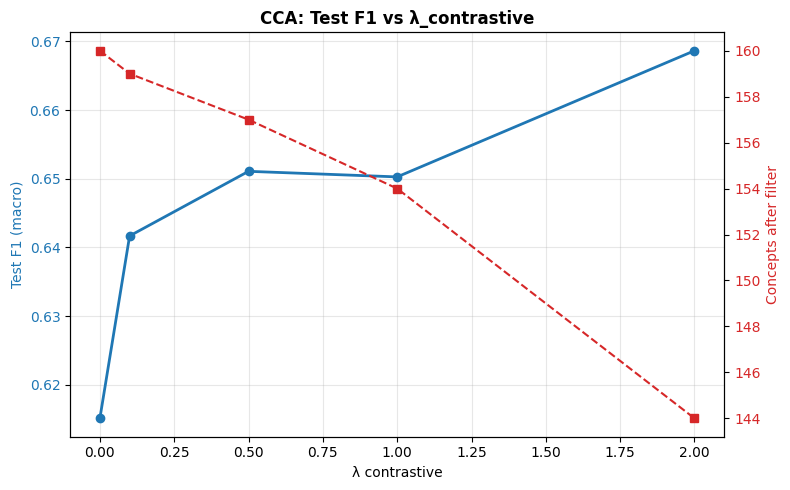


CCA λ sweep summary:
  λ=0.0    K=160   test_F1=0.6151
  λ=0.1    K=159   test_F1=0.6417
  λ=0.5    K=157   test_F1=0.6511
  λ=1.0    K=154   test_F1=0.6503
  λ=2.0    K=144   test_F1=0.6687  ←

Best λ_contrastive: 2.0  (test F1=0.6687)


In [ ]:
# Sweeps the contrastive loss weight λ to find the best CCA operating point.
# For each λ, trains a fresh W_c and evaluates downstream classification F1.
# Outputs a plot of test F1 vs λ for the paper.
import copy

LAMBDA_VALUES   = [0.0, 0.1, 0.5, 1.0, 2.0]   # 0.0 = vanilla LF-CBM baseline
SWEEP_STEPS     = 500    # fewer steps per run to keep sweep tractable
SWEEP_INTERP_C  = 0.20
SWEEP_LR        = CHOSEN_C if 'CHOSEN_C' in dir() else 0.04

sweep_results = []

for lam in LAMBDA_VALUES:
    print("\n" + "="*60)
    print(f"Training CCA with λ_contrastive = {lam}")
    print("="*60)

    # ── Train W_c with this λ ─────────────────────────────────────────────────
    proj_l = nn.Linear(512, K1, bias=False).to(DEVICE)
    opt_l  = torch.optim.Adam(proj_l.parameters(), lr=1e-3)

    crop_it = iter(crop_loader)
    best_v  = float("inf")
    best_w  = None

    for step in range(SWEEP_STEPS):
        proj_l.train()
        b_idx = torch.LongTensor(random.sample(indices, k=PROJ_BATCH))
        t_b   = all_resnet_features[b_idx].to(DEVICE)
        c_b   = STAGE1_RAW_COSINE[b_idx].to(DEVICE)
        o_clip = proj_l(t_b.detach())
        l_clip = torch.mean(-cos_similarity_cubed_single(c_b.detach(), o_clip))

        try:
            c_imgs, c_labels = next(crop_it)
        except StopIteration:
            crop_it = iter(crop_loader)
            c_imgs, c_labels = next(crop_it)
        c_imgs, c_labels = c_imgs.to(DEVICE), c_labels.to(DEVICE)
        with torch.no_grad():
            c_feats = torch.flatten(feature_extractor(c_imgs), 1)
        c_scores = proj_l(c_feats)
        l_contra = contrastive_loss(c_scores, c_labels, temperature=0.07)

        loss = l_clip + lam * l_contra
        loss.backward()
        opt_l.step()
        opt_l.zero_grad()

        if step % 50 == 0 or step == SWEEP_STEPS - 1:
            proj_l.eval()
            with torch.no_grad():
                v_out  = proj_l(val_resnet_feats.to(DEVICE).detach())
                v_loss = torch.mean(-cos_similarity_cubed_single(
                    val_raw_cosine.to(DEVICE).detach(), v_out))
            if v_loss.item() < best_v:
                best_v = v_loss.item()
                best_w = proj_l.weight.clone()
            else:
                break

    proj_l.load_state_dict({"weight": best_w})

    # ── Apply interpretability filter ─────────────────────────────────────────
    proj_l.eval()
    with torch.no_grad():
        v_out = proj_l(val_resnet_feats.to(DEVICE).detach())
        sim_l = cos_similarity_cubed_single(
            val_raw_cosine.to(DEVICE).detach(), v_out)
    interp_l = sim_l > SWEEP_INTERP_C
    K_l      = interp_l.sum().item()

    if K_l == 0:
        print(f"  All concepts filtered out for λ={lam}, skipping.")
        sweep_results.append({"lambda": lam, "K": 0, "test_f1": 0.0})
        continue

    W_l       = proj_l.weight[interp_l]
    proj_lf   = nn.Linear(512, K_l, bias=False)
    proj_lf.load_state_dict({"weight": W_l})
    proj_lf   = proj_lf.to(DEVICE).eval()

    # ── Compute concept scores + classify ─────────────────────────────────────
    tr_c, tr_y = get_concept_scores("train", proj_lf, feature_extractor, CONFIG, resnet_tf)
    te_c, te_y = get_concept_scores("test",  proj_lf, feature_extractor, CONFIG, resnet_tf)

    tr_mean = tr_c.mean(dim=0, keepdim=True)
    tr_std  = tr_c.std(dim=0, keepdim=True).clamp(min=1e-8)
    Xtr     = ((tr_c - tr_mean) / tr_std).numpy()
    Xte     = ((te_c - tr_mean) / tr_std).numpy()

    clf_l = LogisticRegression(
        penalty="elasticnet", solver="saga",
        l1_ratio=0.5, C=0.04, max_iter=3000,
        random_state=42, multi_class="multinomial",
    )
    clf_l.fit(Xtr, tr_y.numpy())
    test_f1_l = f1_score(te_y.numpy(), clf_l.predict(Xte),
                          average="macro", zero_division=0)

    print(f"  λ={lam}  K={K_l}  test_F1={test_f1_l:.4f}")
    sweep_results.append({"lambda": lam, "K": K_l, "test_f1": test_f1_l})

# ── Plot ──────────────────────────────────────────────────────────────────────
lambdas = [r["lambda"]  for r in sweep_results]
f1s     = [r["test_f1"] for r in sweep_results]
ks      = [r["K"]       for r in sweep_results]

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(lambdas, f1s, marker="o", color="tab:blue", linewidth=2, label="Test F1")
ax1.set_xlabel("λ contrastive")
ax1.set_ylabel("Test F1 (macro)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(lambdas, ks, marker="s", color="tab:red", linestyle="--", label="Concepts kept")
ax2.set_ylabel("Concepts after filter", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("CCA: Test F1 vs λ_contrastive", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/cca_lambda_sweep.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
best       = max(sweep_results, key=lambda r: r["test_f1"])
print("\n" + "="*60)
print("CCA λ sweep summary:")
for r in sweep_results:
    marker = "  ←" if r["lambda"] == best["lambda"] else ""
    print(f"  λ={r['lambda']:<5}  K={r['K']:<4}  test_F1={r['test_f1']:.4f}{marker}")
print(f"\nBest λ_contrastive: {best['lambda']}  (test F1={best['test_f1']:.4f})")

##  CCA Concept Bottleneck Layer Training

In [ ]:
LAMBDA_CLIP        = 1.0
LAMBDA_CONTRASTIVE = 2.0
TEMPERATURE        = 0.07
PROJ_STEPS_CCA     = 1000
LR_CCA             = 1e-3

K1             = len(STAGE1_CONCEPTS)
proj_layer_cca = nn.Linear(512, K1, bias=False).to(DEVICE)
opt_cca        = torch.optim.Adam(proj_layer_cca.parameters(), lr=LR_CCA)

N          = all_resnet_features.shape[0]
PROJ_BATCH = min(50000, N)
indices    = list(range(N))

best_val_loss_cca = float("inf")
best_step_cca     = 0
best_weights_cca  = None

crop_iter = iter(crop_loader)

# ── history defined here, appended every 50 steps unconditionally ─────────────
history_cca = {"total": [], "clip": [], "contrastive": [], "val_sim": []}

print("="*60)
print("Training W_c with CCA")
print(f"  λ_clip         = {LAMBDA_CLIP}")
print(f"  λ_contrastive  = {LAMBDA_CONTRASTIVE}")
print(f"  temperature τ  = {TEMPERATURE}")
print(f"  steps          = {PROJ_STEPS_CCA}")
print("="*60)

for step in range(PROJ_STEPS_CCA):
    proj_layer_cca.train()

    # ── CLIP alignment batch ──────────────────────────────────────────────────
    batch_idx    = torch.LongTensor(random.sample(indices, k=PROJ_BATCH))
    target_batch = all_resnet_features[batch_idx].to(DEVICE)
    clip_batch   = STAGE1_RAW_COSINE[batch_idx].to(DEVICE)

    outs_clip = proj_layer_cca(target_batch.detach())
    l_clip    = -cos_similarity_cubed_single(clip_batch.detach(), outs_clip)
    l_clip    = torch.mean(l_clip)

    # ── Contrastive batch ─────────────────────────────────────────────────────
    try:
        crop_imgs, crop_labels = next(crop_iter)
    except StopIteration:
        crop_iter = iter(crop_loader)
        crop_imgs, crop_labels = next(crop_iter)

    crop_imgs   = crop_imgs.to(DEVICE)
    crop_labels = crop_labels.to(DEVICE)

    with torch.no_grad():
        crop_feats = feature_extractor(crop_imgs)
        crop_feats = torch.flatten(crop_feats, 1)

    crop_scores = proj_layer_cca(crop_feats)
    l_contra    = contrastive_loss(crop_scores, crop_labels,
                                   temperature=TEMPERATURE)

    # ── Combined loss ─────────────────────────────────────────────────────────
    loss = LAMBDA_CLIP * l_clip + LAMBDA_CONTRASTIVE * l_contra

    loss.backward()
    opt_cca.step()
    opt_cca.zero_grad()

    # ── Log + validate every 50 steps ────────────────────────────────────────
    if step % 50 == 0 or step == PROJ_STEPS_CCA - 1:
        proj_layer_cca.eval()
        with torch.no_grad():
            val_out  = proj_layer_cca(val_resnet_feats.to(DEVICE).detach())
            val_loss = -cos_similarity_cubed_single(
                val_raw_cosine.to(DEVICE).detach(), val_out)
            val_loss = torch.mean(val_loss)

        # ── Always log before checking early stop ────────────────────────────
        history_cca["total"].append(loss.item())
        history_cca["clip"].append(l_clip.item())
        history_cca["contrastive"].append(l_contra.item())
        history_cca["val_sim"].append(-val_loss.item())

        print(f"  Step {step:4d}  "
              f"clip={l_clip.item():.4f}  "
              f"contra={l_contra.item():.4f}  "
              f"val_sim={-val_loss.item():.4f}")

        if step == 0:
            best_val_loss_cca = val_loss.item()
            best_step_cca     = step
            best_weights_cca  = proj_layer_cca.weight.clone()
        elif val_loss.item() < best_val_loss_cca:
            best_val_loss_cca = val_loss.item()
            best_step_cca     = step
            best_weights_cca  = proj_layer_cca.weight.clone()
        else:
            print(f"  Val loss increasing — early stopping at step {step}.")
            break

proj_layer_cca.load_state_dict({"weight": best_weights_cca})
print(f"\nBest step: {best_step_cca}  "
      f"Best val similarity: {-best_val_loss_cca:.4f}")
print(f"history_cca has {len(history_cca['total'])} logged points.")

torch.save({
    "state_dict":    proj_layer_cca.state_dict(),
    "num_concepts":  K1,
    "concepts":      STAGE1_CONCEPTS,
    "lambda_clip":   LAMBDA_CLIP,
    "lambda_contra": LAMBDA_CONTRASTIVE,
    "temperature":   TEMPERATURE,
}, f"{CONFIG['output_dir']}/concept_layer_cca.pth")
print(f"Saved → {CONFIG['output_dir']}/concept_layer_cca.pth")

Training W_c with CCA
  λ_clip         = 1.0
  λ_contrastive  = 2.0
  temperature τ  = 0.07
  steps          = 1000
  Step    0  clip=0.0041  contra=6.4036  val_sim=-0.0007
  Step   50  clip=-0.1006  contra=4.5114  val_sim=0.1055
  Step  100  clip=-0.2061  contra=4.3433  val_sim=0.2110
  Step  150  clip=-0.2865  contra=4.2508  val_sim=0.2904
  Step  200  clip=-0.3466  contra=4.1897  val_sim=0.3474
  Step  250  clip=-0.3804  contra=4.3888  val_sim=0.3809
  Step  300  clip=-0.4132  contra=4.2761  val_sim=0.4114
  Step  350  clip=-0.4351  contra=4.1886  val_sim=0.4316
  Step  400  clip=-0.4491  contra=4.1406  val_sim=0.4438
  Step  450  clip=-0.4647  contra=4.2470  val_sim=0.4596
  Step  500  clip=-0.4755  contra=4.1363  val_sim=0.4668
  Step  550  clip=-0.4843  contra=4.3153  val_sim=0.4771
  Step  600  clip=-0.4920  contra=4.1289  val_sim=0.4833
  Step  650  clip=-0.4990  contra=4.1940  val_sim=0.4914
  Step  700  clip=-0.5068  contra=4.2422  val_sim=0.4950
  Step  750  clip=-0.5153  co

In [ ]:
INTERPRETABILITY_CUTOFF_CCA = 0.20

proj_layer_cca.eval()
with torch.no_grad():
    val_out_cca = proj_layer_cca(val_resnet_feats.to(DEVICE).detach())
    per_concept_sim_cca = cos_similarity_cubed_single(
        val_raw_cosine.to(DEVICE).detach(), val_out_cca
    )

interpretable_cca = per_concept_sim_cca > INTERPRETABILITY_CUTOFF_CCA

print(f"CCA — Concepts before : {K1}")
print(f"CCA — Concepts kept   : {interpretable_cca.sum().item()}")

FINAL_CONCEPTS_CCA = [STAGE1_CONCEPTS[i]
                      for i in range(K1) if interpretable_cca[i]]
W_c_cca            = proj_layer_cca.weight[interpretable_cca]

proj_layer_cca_final = nn.Linear(512, len(FINAL_CONCEPTS_CCA), bias=False)
proj_layer_cca_final.load_state_dict({"weight": W_c_cca})
proj_layer_cca_final = proj_layer_cca_final.to(DEVICE)
proj_layer_cca_final.eval()

K_cca = len(FINAL_CONCEPTS_CCA)
print(f"CCA — Final concept count: {K_cca}")

# Compute concept scores for all splits
print("\nComputing CCA concept scores...")
train_c_cca, train_y_cca = get_concept_scores(
    "train", proj_layer_cca_final, feature_extractor, CONFIG, resnet_tf)
val_c_cca,   val_y_cca   = get_concept_scores(
    "val",   proj_layer_cca_final, feature_extractor, CONFIG, resnet_tf)
test_c_cca,  test_y_cca  = get_concept_scores(
    "test",  proj_layer_cca_final, feature_extractor, CONFIG, resnet_tf)

# Normalize
train_mean_cca = train_c_cca.mean(dim=0, keepdim=True)
train_std_cca  = train_c_cca.std(dim=0,  keepdim=True).clamp(min=1e-8)

train_c_cca_norm = (train_c_cca - train_mean_cca) / train_std_cca
val_c_cca_norm   = (val_c_cca   - train_mean_cca) / train_std_cca
test_c_cca_norm  = (test_c_cca  - train_mean_cca) / train_std_cca

torch.save(train_mean_cca, f"{CONFIG['output_dir']}/proj_mean_cca.pt")
torch.save(train_std_cca,  f"{CONFIG['output_dir']}/proj_std_cca.pt")
print("CCA concept scores computed and saved.")

CCA — Concepts before : 160
CCA — Concepts kept   : 152
CCA — Final concept count: 152

Computing CCA concept scores...
[TRAIN] 17902 images  (skipped 8967)
[VAL] 3743 images  (skipped 2015)
[TEST] 3785 images  (skipped 1973)
CCA concept scores computed and saved.


## CCA Sparse Classifier and Evaluation

In [ ]:
X_train_cca = train_c_cca_norm.numpy()
y_train_cca = train_y_cca.numpy()
X_val_cca   = val_c_cca_norm.numpy()
y_val_cca   = val_y_cca.numpy()
X_test_cca  = test_c_cca_norm.numpy()
y_test_cca  = test_y_cca.numpy()

# Use SAME C as vanilla for fair comparison
clf_cca = LogisticRegression(
    penalty="elasticnet", solver="saga",
    l1_ratio=0.5, C=CHOSEN_C,
    max_iter=3000, random_state=42,
)
clf_cca.fit(X_train_cca, y_train_cca)

test_preds_cca = clf_cca.predict(X_test_cca)
cca_acc   = accuracy_score(y_test_cca, test_preds_cca) * 100
cca_f1    = f1_score(y_test_cca, test_preds_cca, average="macro",    zero_division=0)
cca_f1_wt = f1_score(y_test_cca, test_preds_cca, average="weighted", zero_division=0)
cca_prec  = precision_score(y_test_cca, test_preds_cca, average="macro", zero_division=0)
cca_rec   = recall_score(y_test_cca,    test_preds_cca, average="macro", zero_division=0)

print("="*50)
print(f"LF-CBM + CCA — TEST RESULTS (C={CHOSEN_C}, λ={LAMBDA_CONTRASTIVE})")
print("="*50)
print(f"  Accuracy          : {cca_acc:.2f}%")
print(f"  F1 (macro)        : {cca_f1:.4f}")
print(f"  F1 (weighted)     : {cca_f1_wt:.4f}")
print(f"  Precision (macro) : {cca_prec:.4f}")
print(f"  Recall (macro)    : {cca_rec:.4f}")
print(f"  Num concepts used : {K_cca}")
print("="*50)
print(classification_report(y_test_cca, test_preds_cca,
                             target_names=CONFIG["class_names"],
                             zero_division=0))

cca_metrics = {
    "model":           "LF-CBM + CCA",
    "num_concepts":    K_cca,
    "C":               CHOSEN_C,
    "lambda_contra":   LAMBDA_CONTRASTIVE,
    "accuracy":        round(cca_acc, 4),
    "f1_macro":        round(cca_f1, 4),
    "f1_weighted":     round(cca_f1_wt, 4),
    "precision_macro": round(cca_prec, 4),
    "recall_macro":    round(cca_rec, 4),
}
with open(f"{CONFIG['output_dir']}/metrics_cca_cbm.json", "w") as f:
    json.dump(cca_metrics, f, indent=2)
print(f"Saved → {CONFIG['output_dir']}/metrics_cca_cbm.json")

LF-CBM + CCA — TEST RESULTS (C=0.04, λ=2.0)
  Accuracy          : 69.30%
  F1 (macro)        : 0.6551
  F1 (weighted)     : 0.6886
  Precision (macro) : 0.6667
  Recall (macro)    : 0.6493
  Num concepts used : 152
                          precision    recall  f1-score   support

Longitudinal Crack (D00)       0.76      0.81      0.78      1609
  Transverse Crack (D10)       0.62      0.47      0.54       582
   Alligator Crack (D20)       0.66      0.71      0.68       778
           Pothole (D40)       0.64      0.61      0.62       816

                accuracy                           0.69      3785
               macro avg       0.67      0.65      0.66      3785
            weighted avg       0.69      0.69      0.69      3785

Saved → /kaggle/working/cbm_rdd2022/metrics_cca_cbm.json


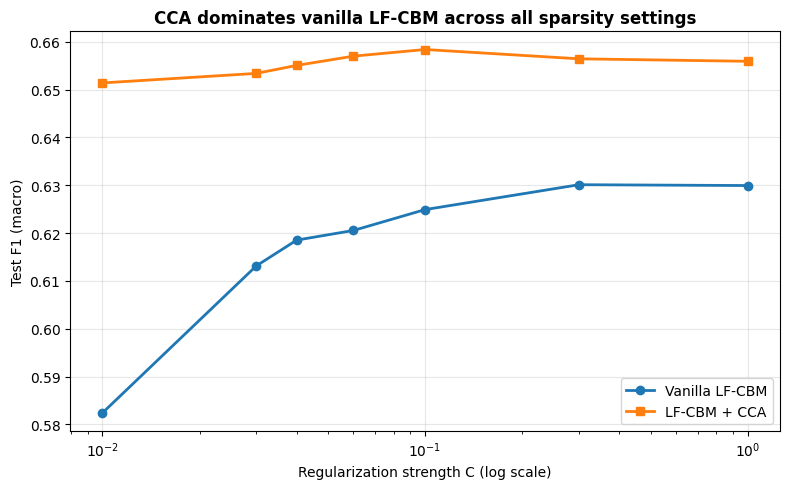

       C     Vanilla         CCA         Δ
---------------------------------------------
  0.01    0.5824      0.6514      +0.0690
  0.03    0.6131      0.6534      +0.0402
  0.04    0.6185      0.6551      +0.0365
  0.06    0.6205      0.6570      +0.0364
  0.1     0.6249      0.6584      +0.0335
  0.3     0.6301      0.6564      +0.0263
  1.0     0.6299      0.6559      +0.0260


In [ ]:
C_grid = [0.01, 0.03, 0.04, 0.06, 0.1, 0.3, 1.0]
vanilla_f1_sweep = []
cca_f1_sweep     = []

for C in C_grid:
    clf_v = LogisticRegression(penalty="elasticnet", solver="saga",
                               l1_ratio=0.5, C=C, max_iter=3000,
                               random_state=42)
    clf_v.fit(X_train, y_train)
    vanilla_f1_sweep.append(
        f1_score(y_test, clf_v.predict(X_test), average="macro", zero_division=0))

    clf_c = LogisticRegression(penalty="elasticnet", solver="saga",
                               l1_ratio=0.5, C=C, max_iter=3000,
                               random_state=42)
    clf_c.fit(X_train_cca, y_train_cca)
    cca_f1_sweep.append(
        f1_score(y_test_cca, clf_c.predict(X_test_cca), average="macro", zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(C_grid, vanilla_f1_sweep, marker="o", linewidth=2, label="Vanilla LF-CBM")
plt.plot(C_grid, cca_f1_sweep,     marker="s", linewidth=2, label="LF-CBM + CCA")
plt.xscale("log")
plt.xlabel("Regularization strength C (log scale)")
plt.ylabel("Test F1 (macro)")
plt.title("CCA dominates vanilla LF-CBM across all sparsity settings",
          fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/vanilla_vs_cca_C_sweep.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"{'C':>8}  {'Vanilla':>10}  {'CCA':>10}  {'Δ':>8}")
print("-"*45)
for C, v, c in zip(C_grid, vanilla_f1_sweep, cca_f1_sweep):
    print(f"  {C:<6}  {v:.4f}      {c:.4f}      {c-v:+.4f}")

In [ ]:
print("\n" + "="*75)
print("FINAL RESULTS COMPARISON TABLE")
print("="*75)
print(f"{'Metric':<25} {'ResNet-18':>12} {'LF-CBM':>10} {'LF-CBM+CCA':>12}")
print("-"*75)

metrics_to_show = [
    ("Accuracy (%)",    "accuracy"),
    ("F1 Macro",        "f1_macro"),
    ("F1 Weighted",     "f1_weighted"),
    ("Precision Macro", "precision_macro"),
    ("Recall Macro",    "recall_macro"),
]

for display_name, key in metrics_to_show:
    r_val = resnet_metrics.get(key, "N/A")
    v_val = cbm_metrics.get(key, "N/A")
    c_val = cca_metrics.get(key, "N/A")
    r_str = f"{r_val:.4f}" if isinstance(r_val, float) else str(r_val)
    v_str = f"{v_val:.4f}" if isinstance(v_val, float) else str(v_val)
    c_str = f"{c_val:.4f}" if isinstance(c_val, float) else str(c_val)
    print(f"  {display_name:<23} {r_str:>12} {v_str:>10} {c_str:>12}")

print("-"*75)
print(f"  {'Requires full labels':<23} {'Yes':>12} {'No':>10} {'No':>12}")
print(f"  {'Interpretable':<23} {'No':>12} {'Yes':>10} {'Yes':>12}")
print(f"  {'Num concepts':<23} {'N/A':>12} "
      f"{cbm_metrics['num_concepts']:>10} {K_cca:>12}")
print(f"  {'Uses bbox supervision':<23} {'No':>12} {'No':>10} {'Yes':>12}")
print("="*75)

# CCA improvement over vanilla
delta_f1  = cca_f1  - cbm_metrics["f1_macro"]
delta_acc = cca_acc - cbm_metrics["accuracy"]
print(f"\nCCA improvement over vanilla LF-CBM:")
print(f"  ΔF1 macro  : {delta_f1:+.4f}")
print(f"  ΔAccuracy  : {delta_acc:+.2f}%")

if delta_f1 > 0:
    print("\n✓ CCA improves concept quality and downstream accuracy.")
    print("  Bounding box contrastive supervision provides a stronger")
    print("  alignment signal than CLIP text similarity alone.")
else:
    print("\n  CCA did not improve F1 at this λ setting.")
    print(f"  Try adjusting LAMBDA_CONTRASTIVE (currently {LAMBDA_CONTRASTIVE}).")
    print("  Values to try: 0.1, 0.3, 1.0, 2.0")


FINAL RESULTS COMPARISON TABLE
Metric                       ResNet-18     LF-CBM   LF-CBM+CCA
---------------------------------------------------------------------------
  Accuracy (%)                 72.3398    66.2616      69.2999
  F1 Macro                      0.6959     0.6185       0.6551
  F1 Weighted                   0.7269     0.6556       0.6886
  Precision Macro               0.6964     0.6365       0.6667
  Recall Macro                  0.7001     0.6104       0.6493
---------------------------------------------------------------------------
  Requires full labels             Yes         No           No
  Interpretable                     No        Yes          Yes
  Num concepts                     N/A        160          152
  Uses bbox supervision             No         No          Yes

CCA improvement over vanilla LF-CBM:
  ΔF1 macro  : +0.0366
  ΔAccuracy  : +3.04%

✓ CCA improves concept quality and downstream accuracy.
  Bounding box contrastive supervision provide

### t-SNE comparison: Vanilla vs CCA concept space
Projects high-dimensional concept score vectors to 2D using t-SNE.
A well-separated projection means the concept space encodes class structure.
Used to visually verify that CCA produces more discriminative concepts than vanilla LF-CBM beyond just headline F1 numbers.

Running t-SNE on vanilla LF-CBM concept scores...
Running t-SNE on CCA concept scores...


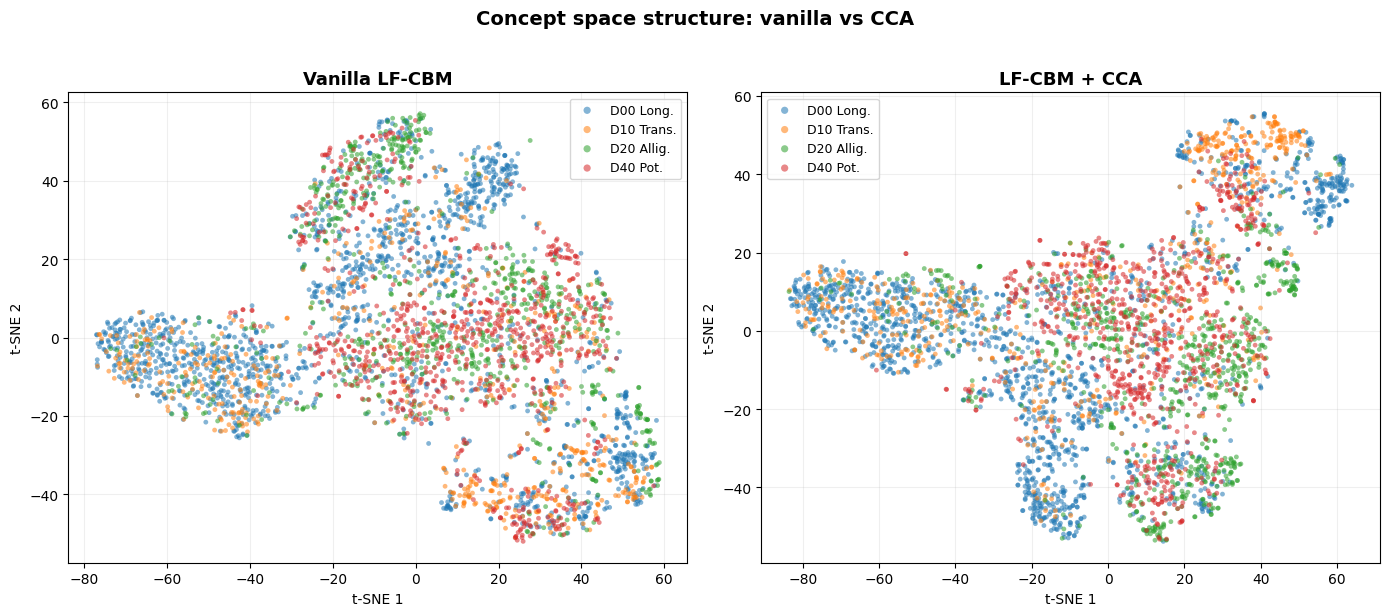


Model                         Silhouette score
------------------------------------------------
  Vanilla LF-CBM                       -0.0641
  LF-CBM + CCA                         -0.0554
  Δ (CCA - vanilla)                    +0.0087


In [ ]:
from sklearn.manifold import TSNE

# ── Run t-SNE on both concept spaces ──────────────────────────────────────────
print("Running t-SNE on vanilla LF-CBM concept scores...")
tsne_vanilla = TSNE(n_components=2, perplexity=30, random_state=42,
                    init="pca", learning_rate="auto").fit_transform(X_test)

print("Running t-SNE on CCA concept scores...")
tsne_cca     = TSNE(n_components=2, perplexity=30, random_state=42,
                    init="pca", learning_rate="auto").fit_transform(X_test_cca)

# ── Plot side-by-side ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

class_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
class_short  = ["D00 Long.", "D10 Trans.", "D20 Allig.", "D40 Pot."]

for ax, embedding, title, labels in zip(
    axes,
    [tsne_vanilla, tsne_cca],
    ["Vanilla LF-CBM", "LF-CBM + CCA"],
    [y_test, y_test_cca],
):
    for cls_id in range(4):
        mask = labels == cls_id
        ax.scatter(embedding[mask, 0], embedding[mask, 1],
                   c=class_colors[cls_id], label=class_short[cls_id],
                   s=12, alpha=0.55, edgecolor="none")
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(loc="best", fontsize=9, markerscale=1.5)
    ax.grid(True, alpha=0.2)

plt.suptitle("Concept space structure: vanilla vs CCA",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/tsne_vanilla_vs_cca.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Quantify cluster quality with silhouette score ────────────────────────────
# Silhouette score in [-1, 1]: higher = better-separated clusters.
# Computed on the full concept space (not the t-SNE projection) to avoid
# distortion from dimensionality reduction.
from sklearn.metrics import silhouette_score

sil_vanilla = silhouette_score(X_test,     y_test)
sil_cca     = silhouette_score(X_test_cca, y_test_cca)

print(f"\n{'Model':<25} {'Silhouette score':>20}")
print("-"*48)
print(f"  {'Vanilla LF-CBM':<23} {sil_vanilla:>20.4f}")
print(f"  {'LF-CBM + CCA':<23} {sil_cca:>20.4f}")
print(f"  {'Δ (CCA - vanilla)':<23} {sil_cca - sil_vanilla:>+20.4f}")

### Expose interpretability layer: per-class top concepts
 For each damage class, extracts the concepts most strongly associated with the prediction (highest positive weight in the sparse classifier).
This is the core interpretability demonstration of the CBM.

VANILLA LF-CBM — Top concepts per class

▸ Longitudinal Crack (D00)
    +0.673  █████████████  a road with a narrow fissure following the length of the carriageway
    +0.654  █████████████  a road surface covered with interlocking angular crack segments
    +0.641  ████████████  a road with a pothole whose interior walls show layered asphalt strata
    +0.446  ████████  a road with a hairline crack following the road axis
    +0.387  ███████  a road with a linear pavement defect running in the travel direction
    +0.356  ███████  a road with multiple branching cracks forming a mesh pattern
    +0.355  ███████  a road with a dark line crossing the asphalt at right angles to travel
    +0.352  ███████  a road with a longitudinal fissure on the paved surface

▸ Transverse Crack (D10)
    +1.368  ███████████████████████████  a road with a narrow transverse crack visible only as a thin dark line across asphalt
    +0.762  ███████████████  a road surface showing a deep rounded cavity from 

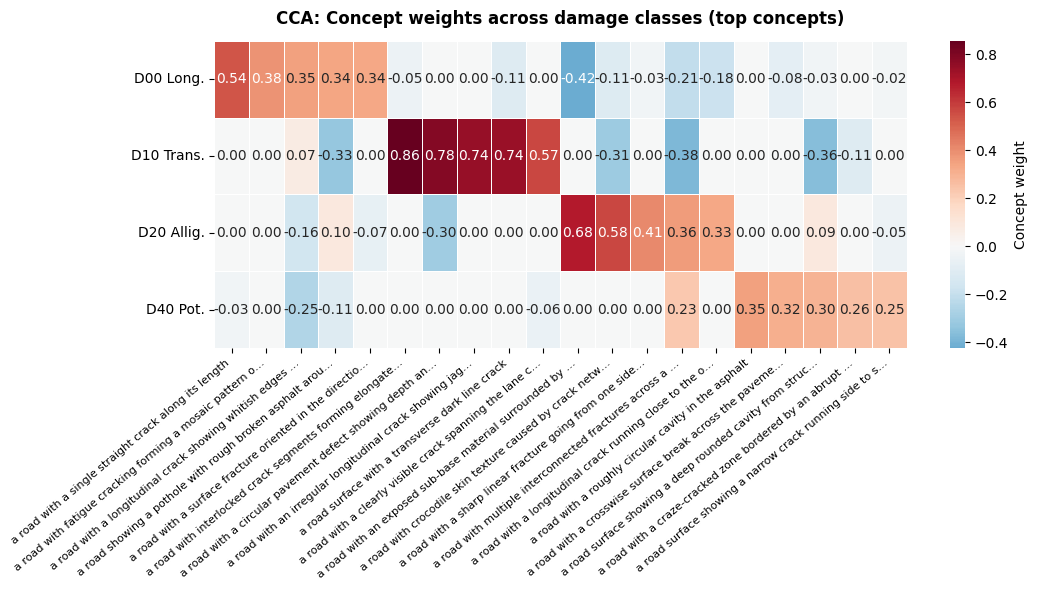

In [ ]:
TOP_K = 8   # top concepts to display per class

def top_concepts_per_class(clf, concept_list, class_names, top_k=8):
    """
    Returns a dict mapping class_name → list of (concept, weight) tuples.
    Sorted by weight descending, only positive weights returned.
    """
    coef = clf.coef_   # [num_classes, num_concepts]
    out  = {}
    for cls_id, cls_name in enumerate(class_names):
        weights      = coef[cls_id]
        top_indices  = np.argsort(weights)[::-1][:top_k]
        out[cls_name] = [(concept_list[i], weights[i])
                         for i in top_indices if weights[i] > 0]
    return out

# ── Vanilla LF-CBM ────────────────────────────────────────────────────────────
print("="*75)
print("VANILLA LF-CBM — Top concepts per class")
print("="*75)
top_vanilla = top_concepts_per_class(clf, FINAL_CONCEPTS,
                                     CONFIG["class_names"], top_k=TOP_K)
for cls_name, items in top_vanilla.items():
    print(f"\n▸ {cls_name}")
    for concept, w in items:
        bar = "█" * int(w * 20)
        print(f"    {w:+.3f}  {bar}  {concept}")

# ── LF-CBM + CCA ──────────────────────────────────────────────────────────────
print("\n\n" + "="*75)
print("LF-CBM + CCA — Top concepts per class")
print("="*75)
top_cca = top_concepts_per_class(clf_cca, FINAL_CONCEPTS_CCA,
                                  CONFIG["class_names"], top_k=TOP_K)
for cls_name, items in top_cca.items():
    print(f"\n▸ {cls_name}")
    for concept, w in items:
        bar = "█" * int(w * 20)
        print(f"    {w:+.3f}  {bar}  {concept}")

# ── Save to JSON for the paper ────────────────────────────────────────────────
interpretability_export = {
    "vanilla_lfcbm": {
        cls: [{"concept": c, "weight": float(w)} for c, w in items]
        for cls, items in top_vanilla.items()
    },
    "lfcbm_cca": {
        cls: [{"concept": c, "weight": float(w)} for c, w in items]
        for cls, items in top_cca.items()
    },
}
with open(f"{CONFIG['output_dir']}/top_concepts_per_class.json", "w") as f:
    json.dump(interpretability_export, f, indent=2)
print(f"\nSaved → {CONFIG['output_dir']}/top_concepts_per_class.json")

# ── Visual: heatmap of top concepts (CCA only, paper figure) ─────────────────
# Build a matrix [num_classes, num_top_concepts] showing weights
fig, ax = plt.subplots(figsize=(11, 6))

# Collect a unique union of top concepts across all classes for the heatmap
all_top_concepts = []
seen = set()
for items in top_cca.values():
    for concept, _ in items[:5]:   # top 5 per class for the heatmap
        if concept not in seen:
            all_top_concepts.append(concept)
            seen.add(concept)

# Build weight matrix
weight_matrix = np.zeros((4, len(all_top_concepts)))
for cls_id in range(4):
    for j, concept in enumerate(all_top_concepts):
        idx = FINAL_CONCEPTS_CCA.index(concept)
        weight_matrix[cls_id, j] = clf_cca.coef_[cls_id, idx]

# Truncate concept text for readability
short_concepts = [c[:55] + "…" if len(c) > 55 else c for c in all_top_concepts]

sns.heatmap(weight_matrix, ax=ax,
            xticklabels=short_concepts,
            yticklabels=["D00 Long.", "D10 Trans.", "D20 Allig.", "D40 Pot."],
            cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            cbar_kws={"label": "Concept weight"},
            linewidths=0.4, linecolor="white")
ax.set_title("CCA: Concept weights across damage classes (top concepts)",
             fontweight="bold", pad=12)
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/concept_weights_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

### GradCAM: spatial attribution comparison
 Generates GradCAM heatmaps for ResNet-18, vanilla LF-CBM, and LF-CBM+CCA on the same test images. Shows which spatial regions each model uses to make its prediction. Trustworthy attention = focused on actual damage region.

Selected 4 example images, one per class.


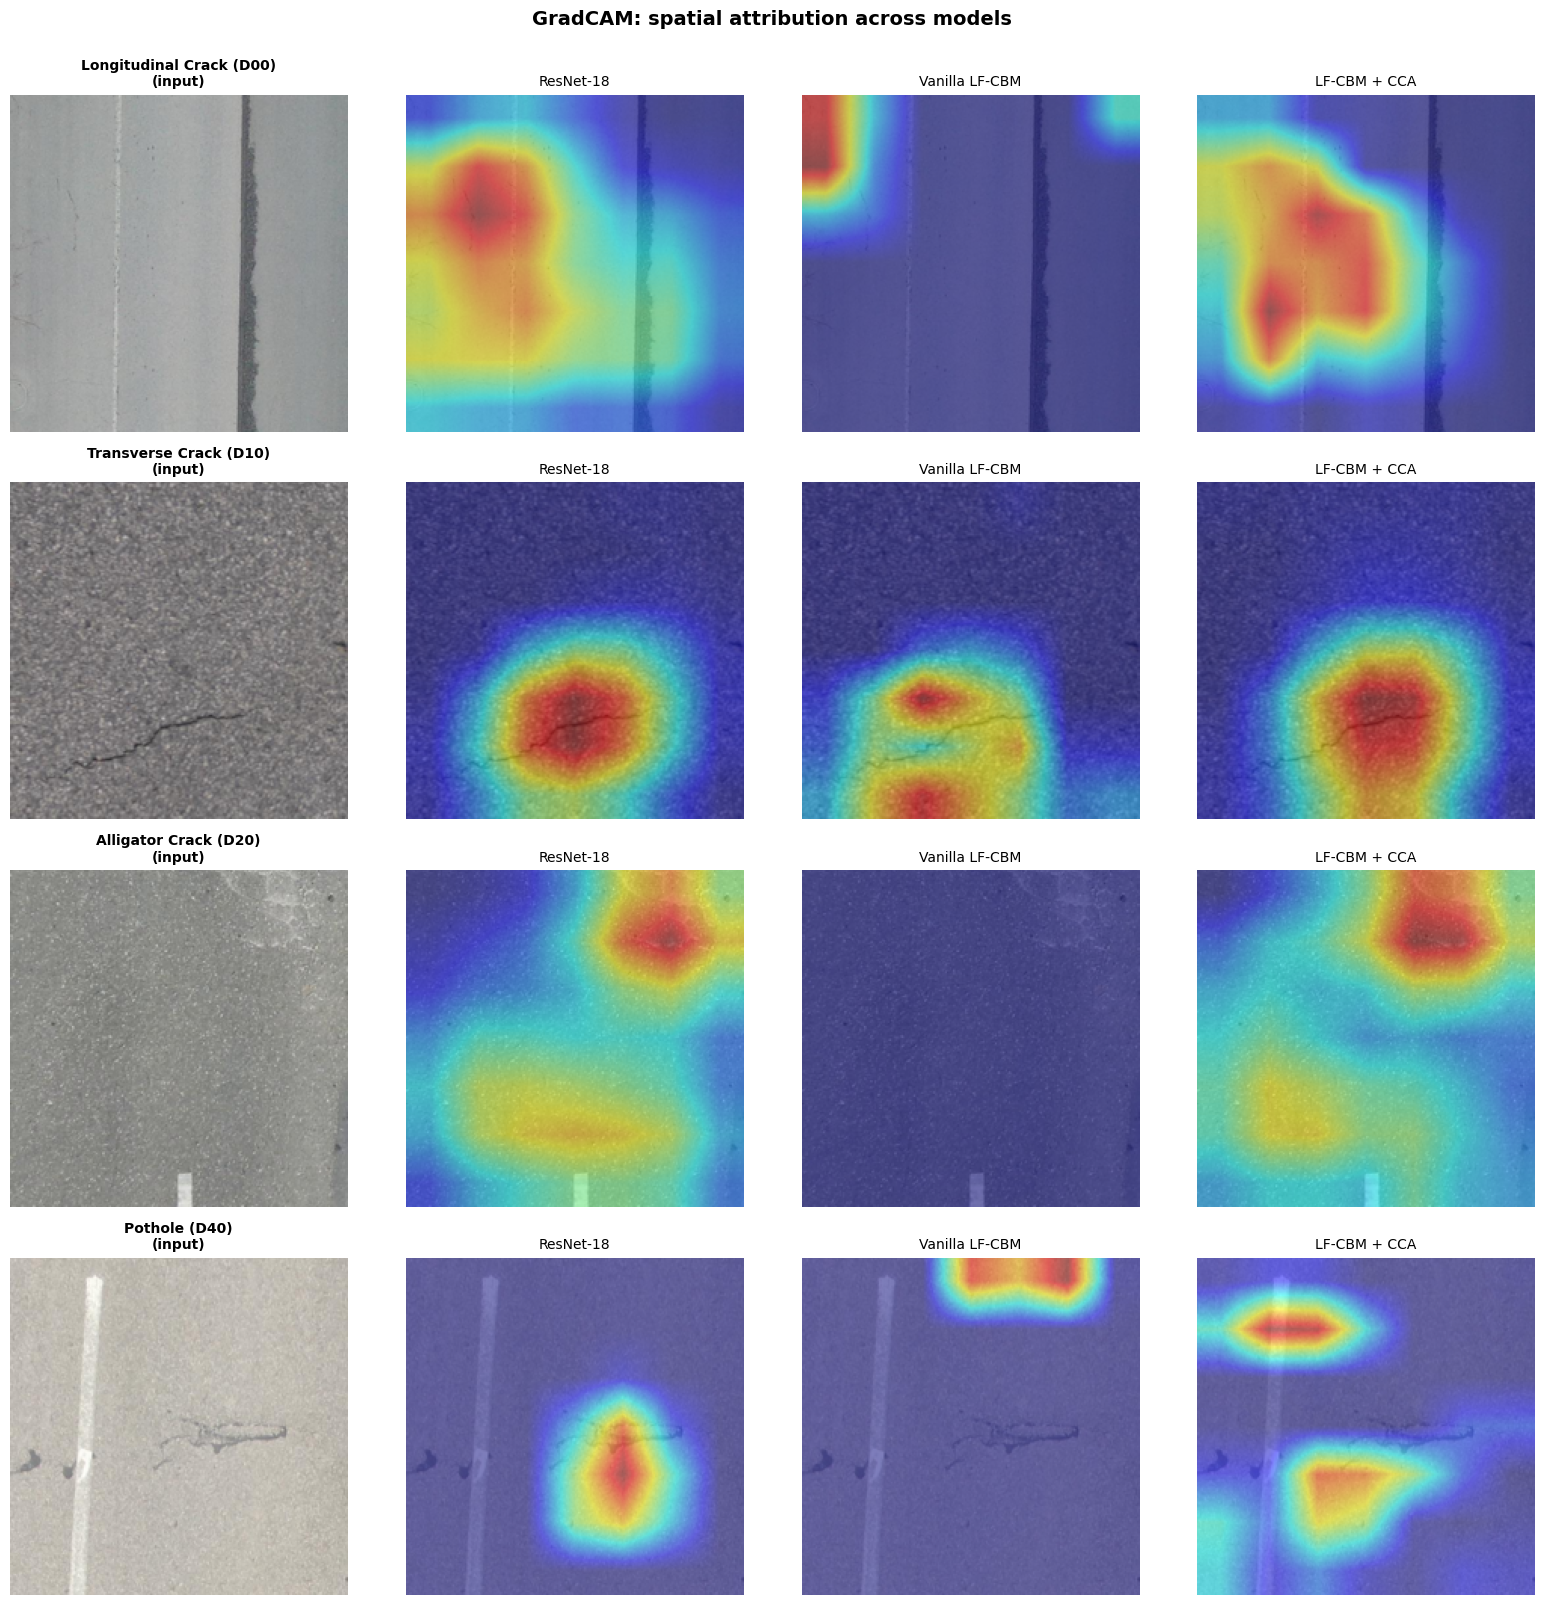

In [ ]:
import torch.nn.functional as F
import cv2

# ── GradCAM hook utility ──────────────────────────────────────────────────────
class GradCAM:
    """
    Standard GradCAM implementation. Hooks into a target conv layer to capture
    activations and gradients, then computes a class-discriminative heatmap.
    """
    def __init__(self, model, target_layer):
        self.model        = model
        self.activations  = None
        self.gradients    = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, input_tensor, target_class):
        self.model.zero_grad()
        output = self.model(input_tensor)
        if output.dim() == 1:
            output = output.unsqueeze(0)
        score = output[0, target_class]
        score.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)   # [1, C, 1, 1]
        cam     = (weights * self.activations).sum(dim=1).squeeze(0)
        cam     = F.relu(cam)
        cam     = cam - cam.min()
        cam     = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy()

# ── Wrappers so the three models share a common forward signature ────────────
class CBMWrapper(nn.Module):
    """Wraps feature_extractor + proj_layer + sparse classifier into one model."""
    def __init__(self, feat_extractor, proj_layer, clf, train_mean, train_std):
        super().__init__()
        self.feat = feat_extractor
        self.proj = proj_layer
        # sklearn classifier → torch linear for gradient flow
        coef = torch.tensor(clf.coef_,      dtype=torch.float32, device=DEVICE)
        bias = torch.tensor(clf.intercept_, dtype=torch.float32, device=DEVICE)
        self.linear = nn.Linear(coef.shape[1], coef.shape[0]).to(DEVICE)
        with torch.no_grad():
            self.linear.weight.copy_(coef)
            self.linear.bias.copy_(bias)
        self.mean = train_mean.to(DEVICE)
        self.std  = train_std.to(DEVICE)

    def forward(self, x):
        f = self.feat(x)
        f = torch.flatten(f, 1)
        c = self.proj(f)
        c = (c - self.mean) / self.std
        return self.linear(c)

# ── Build the three models ────────────────────────────────────────────────────
backbone.eval()      # already loaded in Cell 5
target_layer_resnet  = backbone.layer4[-1]
target_layer_feat    = feature_extractor[-2]   # last conv block of feature_extractor

cbm_vanilla = CBMWrapper(feature_extractor, proj_layer_final, clf,
                         train_mean, train_std)
cbm_cca     = CBMWrapper(feature_extractor, proj_layer_cca_final, clf_cca,
                         train_mean_cca, train_std_cca)
cbm_vanilla.eval()
cbm_cca.eval()

gradcam_resnet  = GradCAM(backbone,    target_layer_resnet)
gradcam_vanilla = GradCAM(cbm_vanilla, target_layer_feat)
gradcam_cca     = GradCAM(cbm_cca,     target_layer_feat)

# ── Pick one example image per damage class ──────────────────────────────────
test_img_dir = Path(CONFIG["base_dir"]) / "test" / "images"
test_lbl_dir = Path(CONFIG["base_dir"]) / "test" / "labels"

def find_example_per_class():
    """Find one image whose majority label is each class, where all 3 models predict correctly."""
    examples = {}
    for img_path in sorted(test_img_dir.glob("*.jpg")):
        if len(examples) == 4:
            break
        txt_path = test_lbl_dir / (img_path.stem + ".txt")
        if not txt_path.exists():
            continue
        try:
            ids = []
            with open(txt_path) as f:
                for line in f:
                    p = line.strip().split()
                    if len(p) == 5 and int(p[0]) in {0,1,2,3}:
                        ids.append(int(p[0]))
            if not ids:
                continue
            label = Counter(ids).most_common(1)[0][0]
        except Exception:
            continue
        if label in examples:
            continue
        examples[label] = img_path
    return examples

examples = find_example_per_class()
print(f"Selected {len(examples)} example images, one per class.")

# ── Generate GradCAMs and plot ────────────────────────────────────────────────
def overlay_cam(img_pil, cam, alpha=0.5):
    """Resize CAM to image size, colormap it, blend with image."""
    img_np  = np.array(img_pil.resize((224, 224))).astype(np.float32) / 255.0
    cam_re  = cv2.resize(cam, (224, 224))
    cam_col = cv2.applyColorMap(np.uint8(255 * cam_re), cv2.COLORMAP_JET)
    cam_col = cv2.cvtColor(cam_col, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    blended = (1 - alpha) * img_np + alpha * cam_col
    return np.clip(blended, 0, 1)

fig, axes = plt.subplots(len(examples), 4, figsize=(16, 4 * len(examples)))
if len(examples) == 1:
    axes = axes[None, :]

for row_idx, (cls_id, img_path) in enumerate(sorted(examples.items())):
    img    = Image.open(img_path).convert("RGB")
    img_t  = resnet_tf(img).unsqueeze(0).to(DEVICE)

    # ResNet-18 GradCAM
    cam_r = gradcam_resnet(img_t, cls_id)
    # Vanilla LF-CBM GradCAM
    cam_v = gradcam_vanilla(img_t, cls_id)
    # CCA GradCAM
    cam_c = gradcam_cca(img_t, cls_id)

    axes[row_idx, 0].imshow(img.resize((224, 224)))
    axes[row_idx, 0].set_title(f"{CONFIG['class_names'][cls_id]}\n(input)",
                                fontweight="bold", fontsize=10)
    axes[row_idx, 1].imshow(overlay_cam(img, cam_r))
    axes[row_idx, 1].set_title("ResNet-18", fontsize=10)
    axes[row_idx, 2].imshow(overlay_cam(img, cam_v))
    axes[row_idx, 2].set_title("Vanilla LF-CBM", fontsize=10)
    axes[row_idx, 3].imshow(overlay_cam(img, cam_c))
    axes[row_idx, 3].set_title("LF-CBM + CCA", fontsize=10)

    for col in range(4):
        axes[row_idx, col].axis("off")

plt.suptitle("GradCAM: spatial attribution across models",
             fontweight="bold", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/gradcam_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()